# Dataset description :

This notebook presents an end-to-end regression workflow using the target variable `annual_medical_cost`.

We will cover:

1. **Exploratory Data Analysis (EDA)** with visualizations  
2. **Data preprocessing**
   - Missing values handling
   - Duplicate removal
   - Outlier detection and handling
   - Data consistency correction
   - Format standardization
3. **Data transformation**
   - Categorical encoding
   - Feature scaling / normalization
   - Feature transformation
   - Feature engineering
   - Feature selection
4. **Training and comparing multiple regression models**
5. **Evaluation using several metrics and validation techniques**
6. **Inference function** for predicting insurance charges from user inputs

> Dataset file used: `insurance.csv`

This dataset includes :
1. Demographics & Socioeconomic:
person_id, age, sex, region, urban_rural, income, education, marital_status, employment_status, household_size, dependents

2. Lifestyle & Habits:
bmi, smoker, alcohol_freq

3. Health & Clinical:
hypertension, diabetes, copd, cardiovascular, cancer_history, kidney_disease, liver_disease, arthritis, mental_health, chronic_count, systolic_bp, diastolic_bp, ldl, hba1c, risk_score, is_high_risk

4. Healthcare Utilization & Procedures:
visits_last_year, hospitalizations_last_3yrs, days_hospitalized_last_3yrs, medication_count, proc_imaging_count, proc_surgery_count, proc_physio_count, proc_consult_count, proc_lab_count, had_major_procedure

5. Insurance & Policy:
plan_type, network_tier, deductible, copay, policy_term_years, policy_changes_last_2yrs, provider_quality

6. Medical Costs & Claims:
annual_medical_cost, annual_premium, monthly_premium, claims_count, avg_claim_amount, total_claims_paid

In [348]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OrdinalEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

## 1. Loading the dataset

In [349]:
data_path = "medical_insurance.csv"
target_col = "annual_medical_cost"
df = pd.read_csv(data_path)
print("Using dataset:", data_path)
print("Shape:", df.shape)

display(df.head())

Using dataset: medical_insurance.csv
Shape: (100000, 54)


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


In our predictions the `person_id` won't affect our outcomes, thus we are able to remove this feature. Moreover `monthly_premium` and `annual_premium` are theoreticaly the same as `annual_medical_cost`, so we also going to remove them.

In [350]:
df.drop(columns=["person_id"], inplace=True)
df.drop(columns=["monthly_premium"], inplace=True)
df.drop(columns=["annual_premium"], inplace=True)

## 2. Dataset Overview

We check for:
- data types
- missing values
- duplicates
- descriptive statistic

In [351]:
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 51 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   age                          100000 non-null  int64  
 1   sex                          100000 non-null  str    
 2   region                       100000 non-null  str    
 3   urban_rural                  100000 non-null  str    
 4   income                       100000 non-null  float64
 5   education                    100000 non-null  str    
 6   marital_status               100000 non-null  str    
 7   employment_status            100000 non-null  str    
 8   household_size               100000 non-null  int64  
 9   dependents                   100000 non-null  int64  
 10  bmi                          100000 non-null  float64
 11  smoker                       100000 non-null  str    
 12  alcohol_freq                 69917 non-null   str    
 13  visits_last

None

In [352]:
display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,100000.0,NaN,NaN,NaN,47.5215,15.988752,0.0,37.0,48.0,58.0,100.0
sex,100000,3,Female,49193,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,100000,5,South,28029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
urban_rural,100000,3,Urban,60019,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income,100000.0,NaN,NaN,NaN,49873.905,46800.214127,1100.0,21100.0,36200.0,62200.0,1061800.0
education,100000,6,Bachelors,27996,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital_status,100000,4,Married,53252,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_status,100000,4,Employed,55269,NaN,NaN,NaN,NaN,NaN,NaN,NaN
household_size,100000.0,NaN,NaN,NaN,2.4309,1.075126,1.0,2.0,2.0,3.0,9.0
dependents,100000.0,NaN,NaN,NaN,0.89838,0.950654,0.0,0.0,1.0,1.0,7.0


In [353]:
# Checking for missing data

print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing_count"))


Missing values per column:


,missing_count
age,0
sex,0
region,0
urban_rural,0
income,0
education,0
marital_status,0
employment_status,0
household_size,0
dependents,0


## 3. Exploratory Data Analysis (EDA)

We will explore:
- the distribution of the target `annual_medical_cost`
- distributions of numerical features
- counts of categorical features
- relationships between features and target
- correlation structure among numerical features


In [354]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

binary_cols = [
    col for col in df.columns
    if df[col].nunique() == 2 and set(df[col].dropna().unique()) <= {0, 1}
]

numeric_cols = [col for col in numeric_cols if col not in binary_cols]
categorical_cols = categorical_cols + binary_cols

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['age', 'income', 'household_size', 'dependents', 'bmi', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'risk_score', 'annual_medical_cost', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'chronic_count', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count']
Categorical columns: ['sex', 'region', 'urban_rural', 'education', 'marital_status', 'employment_status', 'smoker', 'alcohol_freq', 'plan_type', 'network_tier', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'is_high_risk', 'had_major_procedure']


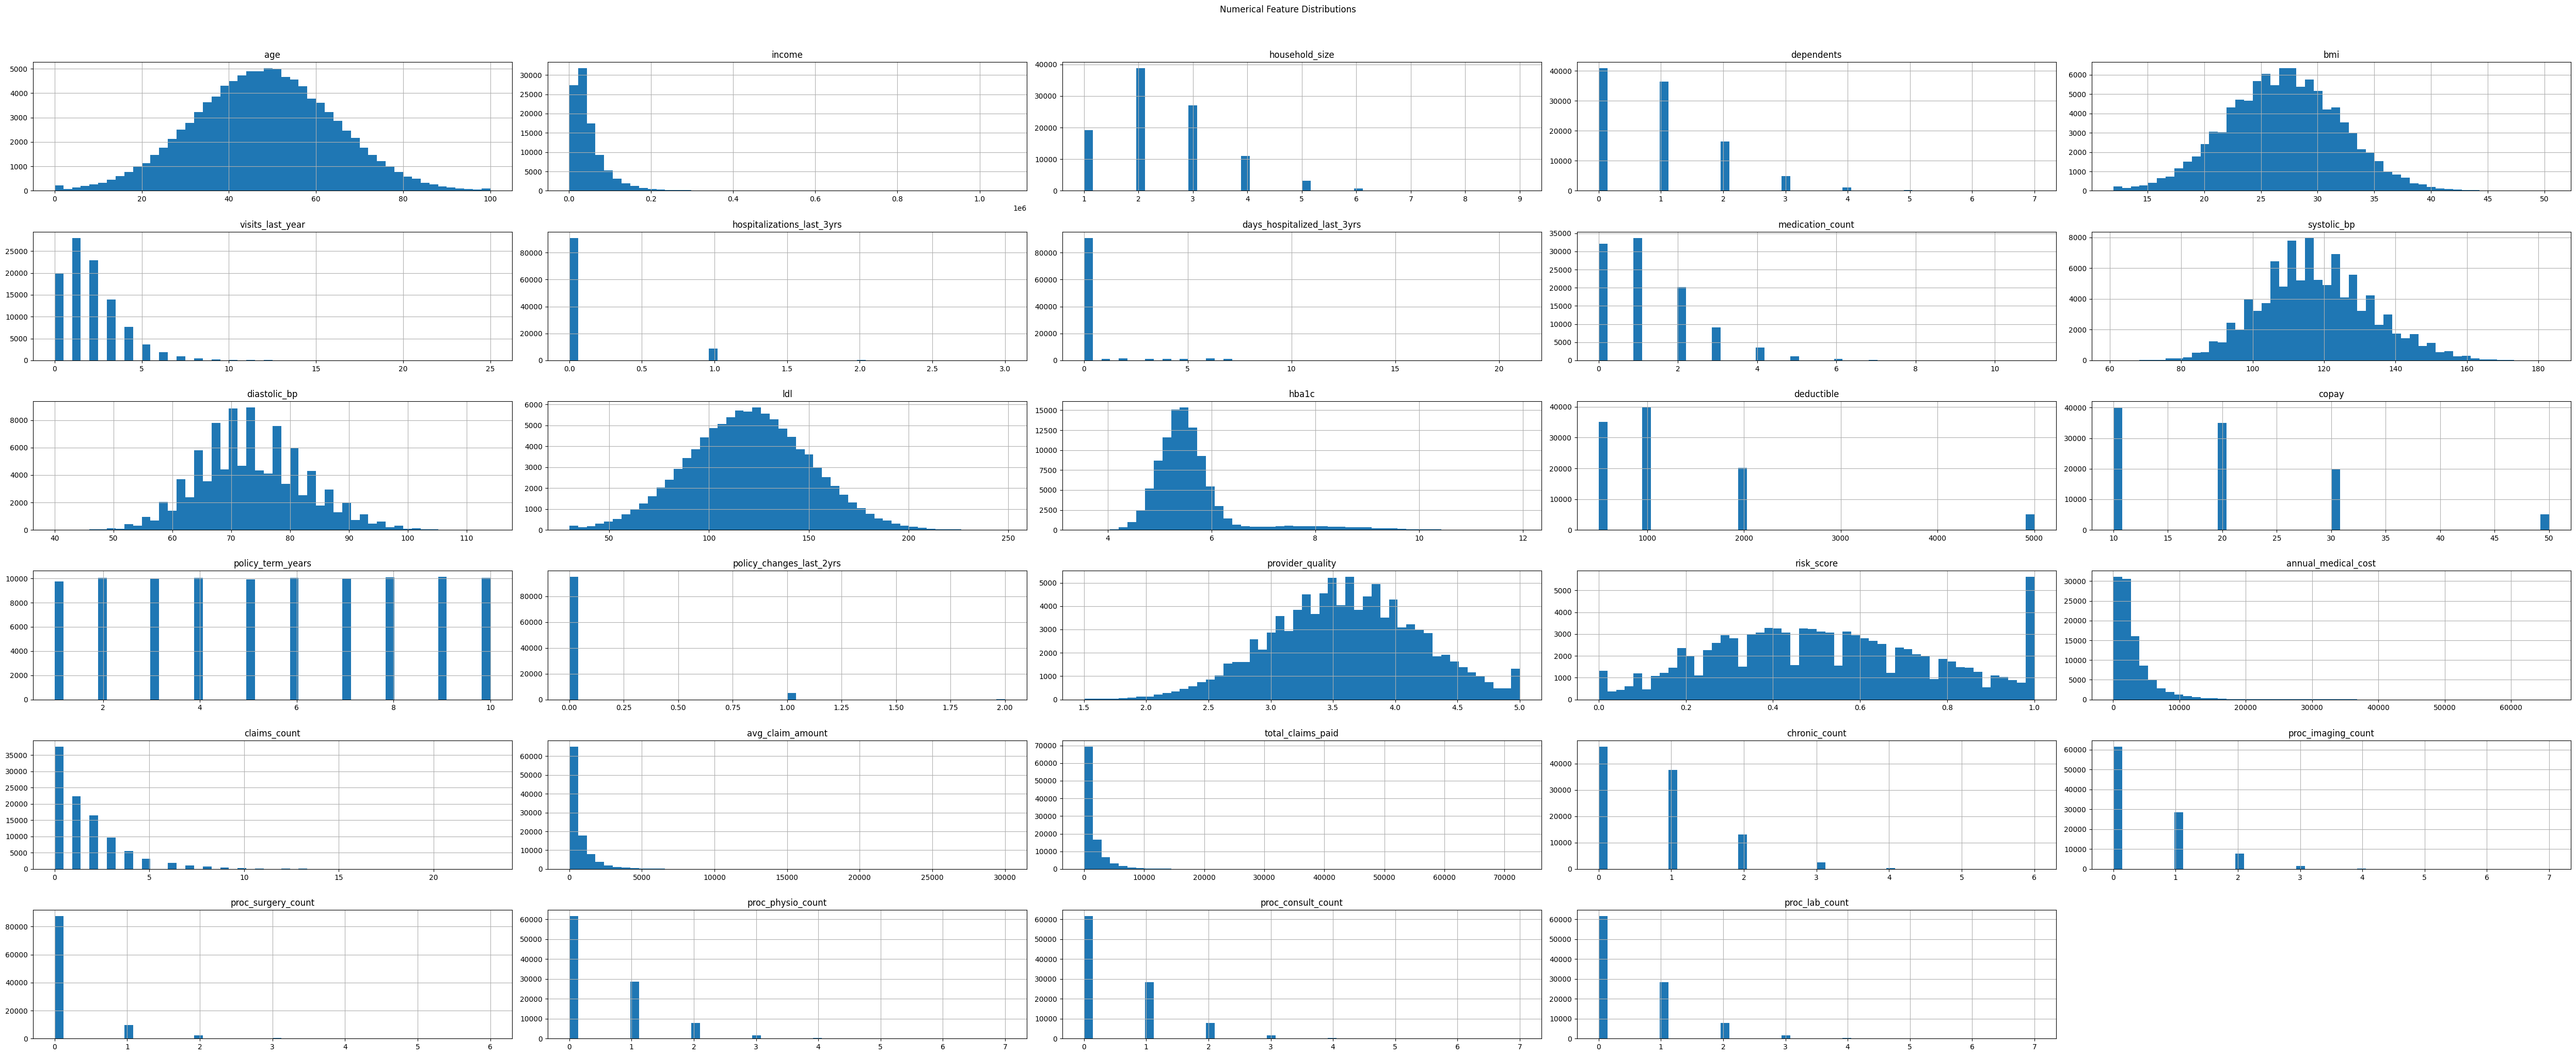

In [355]:
# Histograms for numerical features
df[numeric_cols].hist(bins=50, figsize=(50, 20))
plt.suptitle("Numerical Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

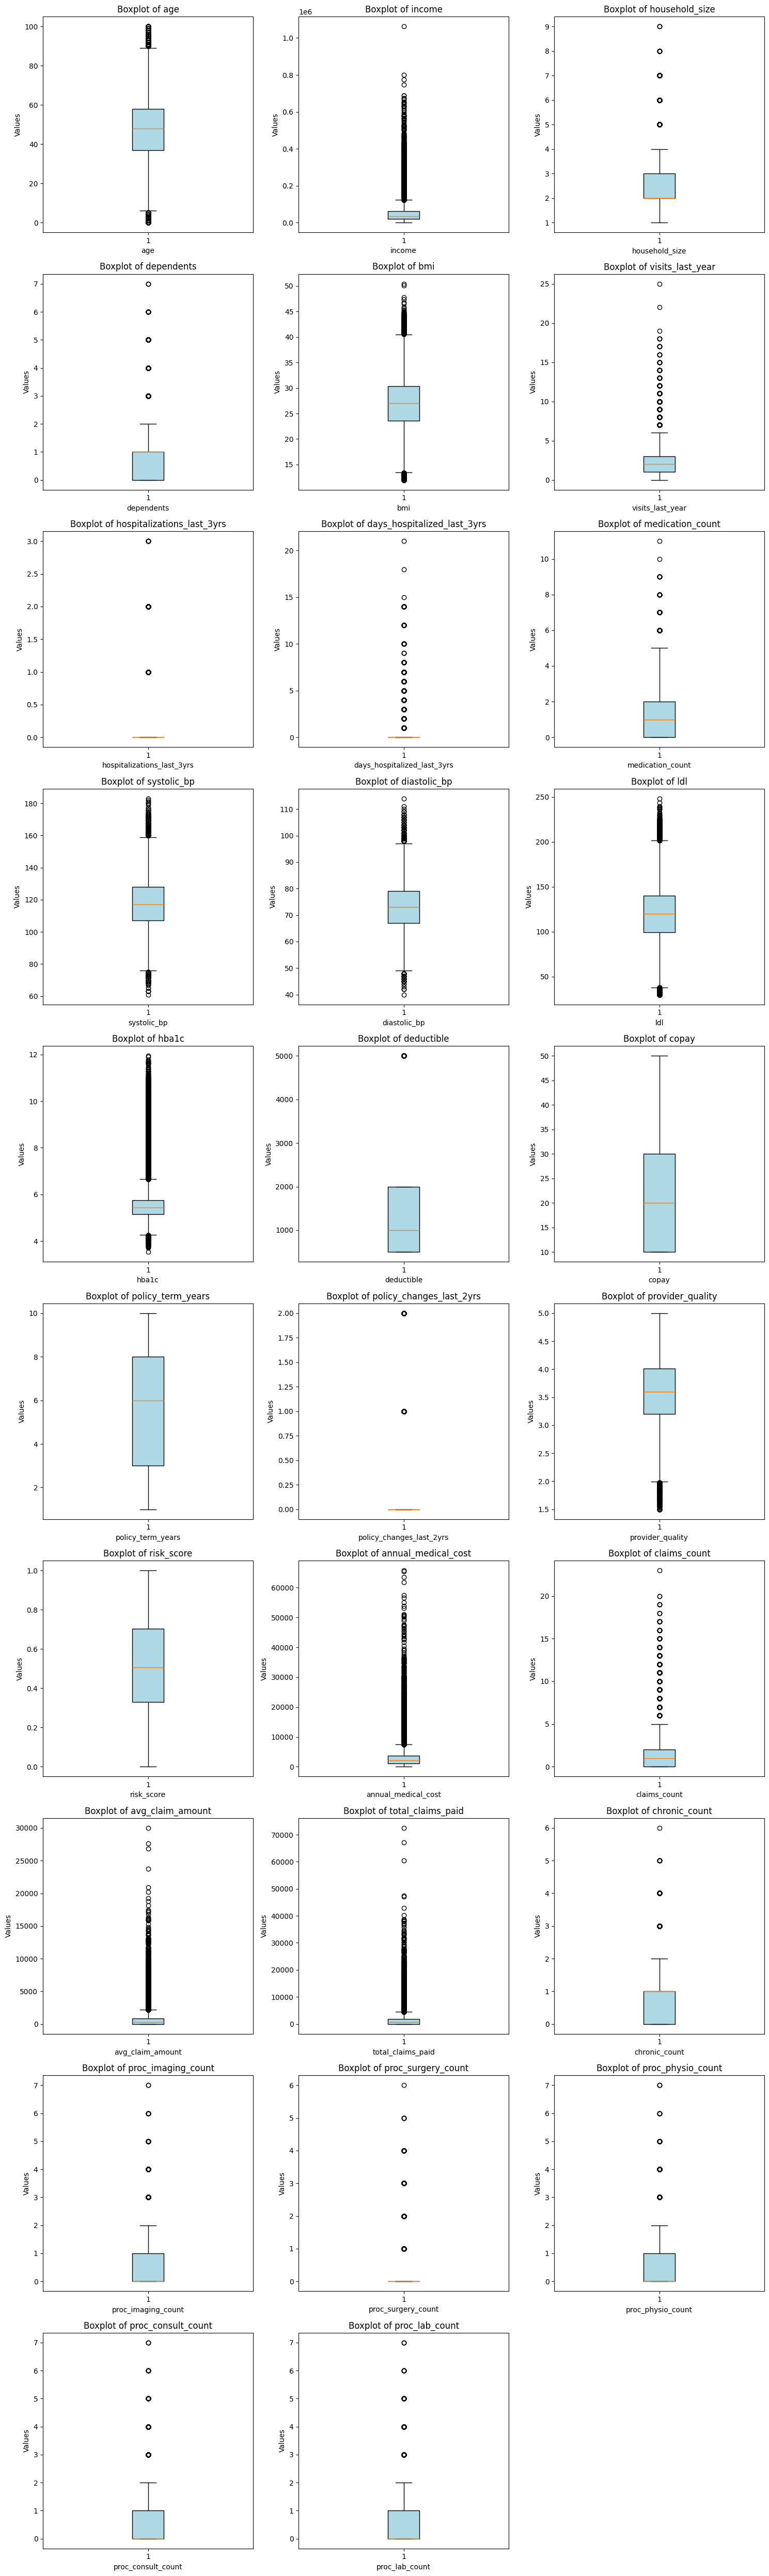

In [356]:
n_cols = 3
n_rows = (len(numeric_cols) // n_cols) + (len(numeric_cols) % n_cols > 0)

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(numeric_cols):
    # Dynamically place each plot in the grid
    plt.subplot(n_rows, n_cols, i + 1)
    
    # The Boxplot logic from Video 2
    plt.boxplot(df[col].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='black'),
                capprops=dict(color='black'),
                whiskerprops=dict(color='black'),
                flierprops=dict(markeredgecolor='black', marker='o'))
    
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.ylabel('Values')

plt.tight_layout()
plt.show()

Needs full rework this is from the old dsataset
after scaling some of the stuff will change


1. Boxplot of CGPA
The median CGPA is centrally located within a symmetrical box, showing a consistent academic standard across the student body.
There are no significant outliers, indicating that the academic data is clean and falls within the expected range of 0 to 10.

2. Boxplot of Coding Skill Score
The median coding score sits in the middle of the range, but the upper whiskers reveal a select group of high-performing programmers.
A few outliers exist on both ends, representing students with either exceptional mastery or significant gaps in programming skills.

3. Boxplot of Internships/Projects
Most students have completed 1 to 2 internships, creating a concentrated box with a very narrow spread.
The data is uniform and free of extreme outliers after capping, ensuring that "star" students don't over-influence the general trend.

4. Boxplot of Salary (Target Variable)
The distribution is heavily right-skewed, with most placement packages concentrated at the lower end of the scale.
Multiple high-end outliers represent elite salary packages, which we addressed using a log transformation to stabilize the model's predictions.

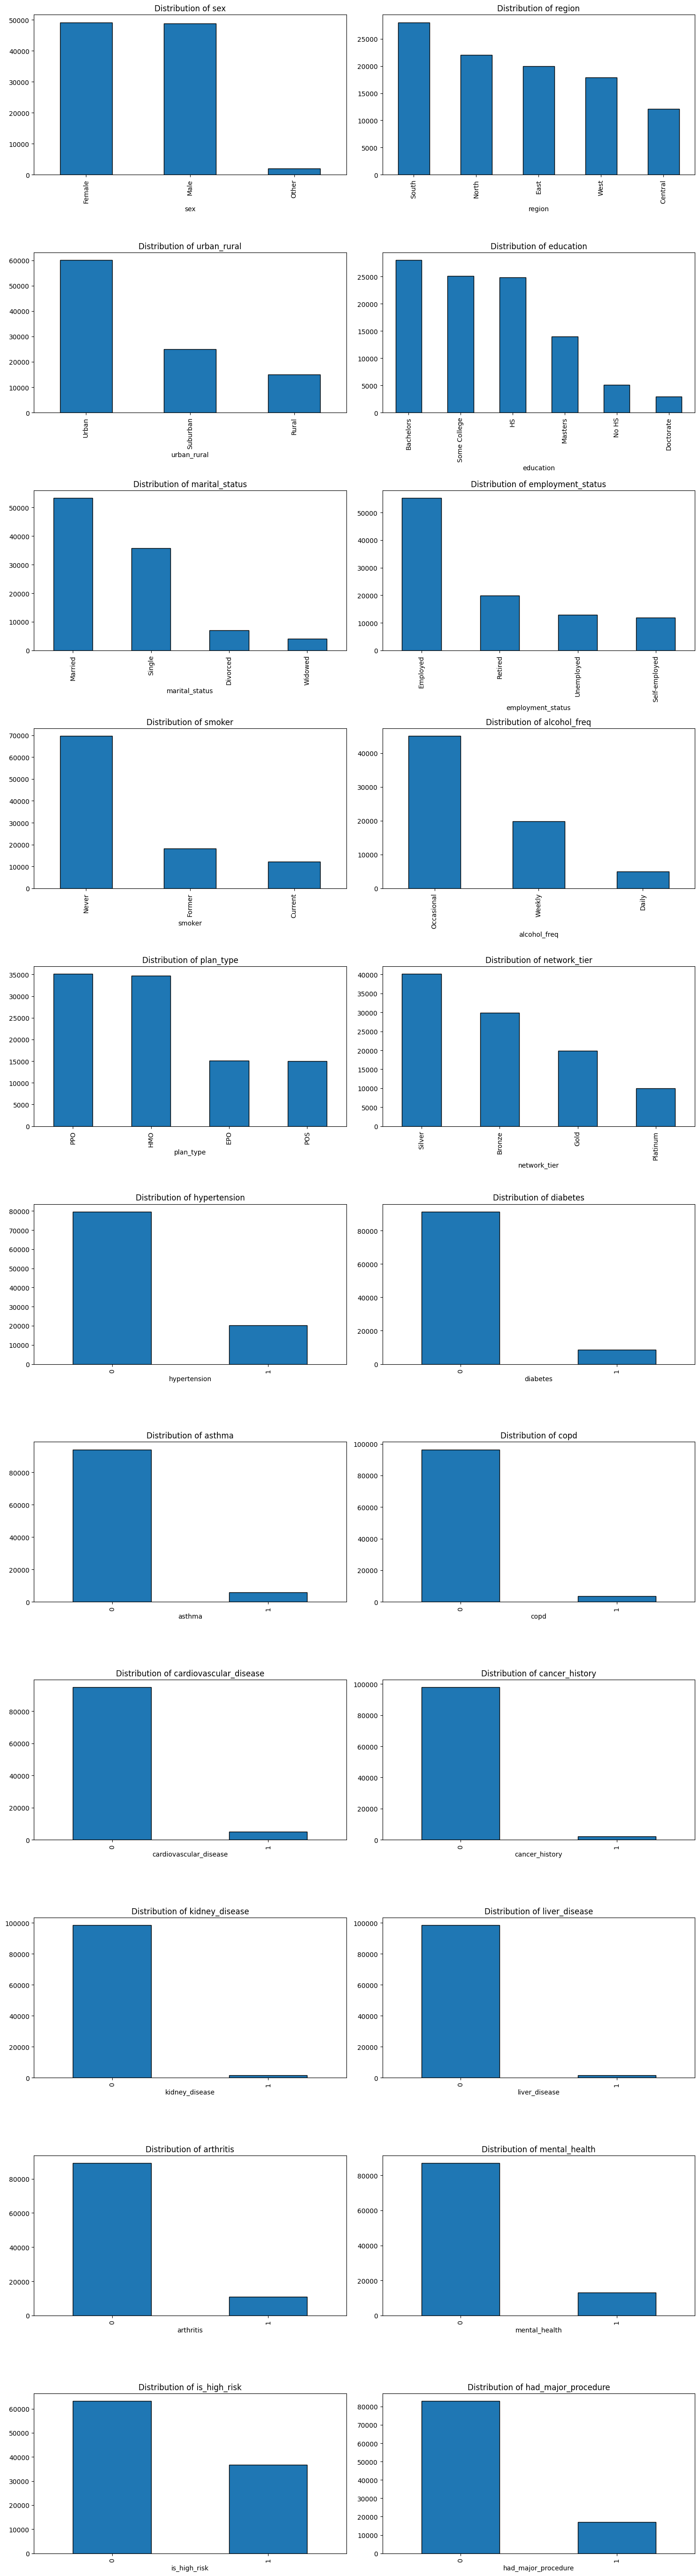

In [357]:
n_cols = 2
n_rows = math.ceil(len(categorical_cols) / n_cols)

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(categorical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    df[col].value_counts().plot(kind='bar', edgecolor='black')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

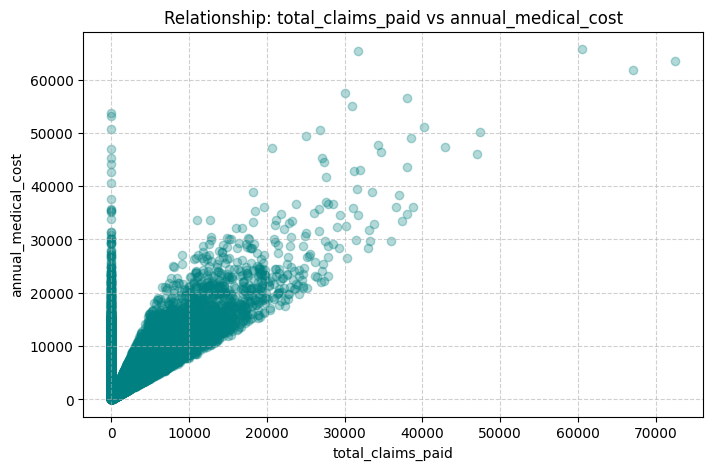

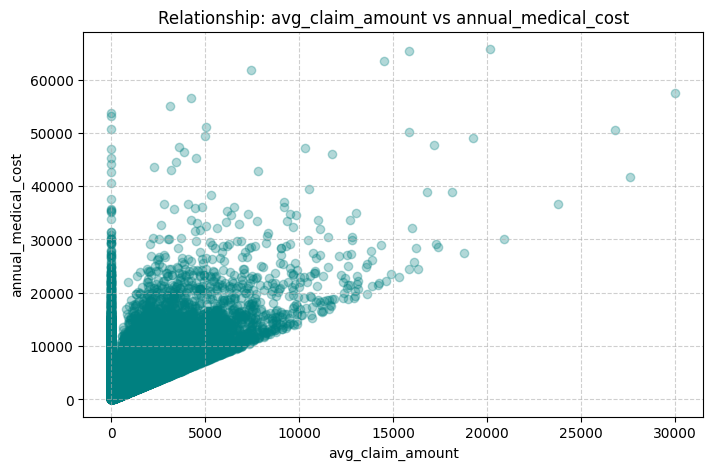

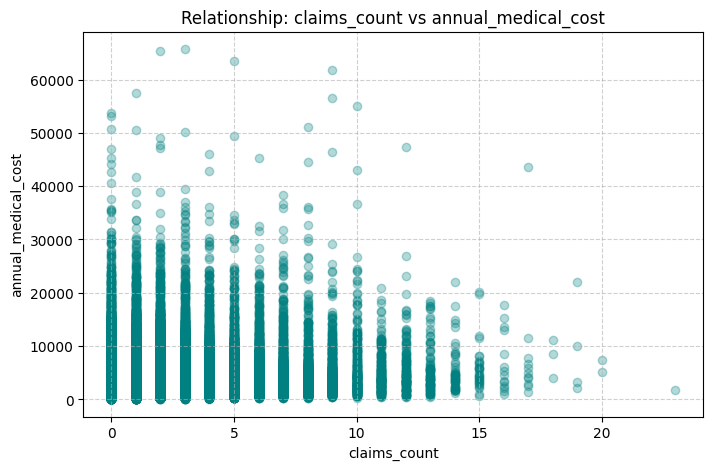

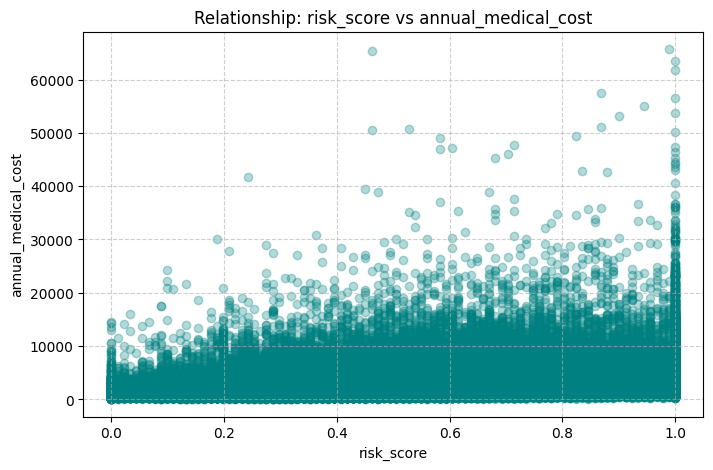

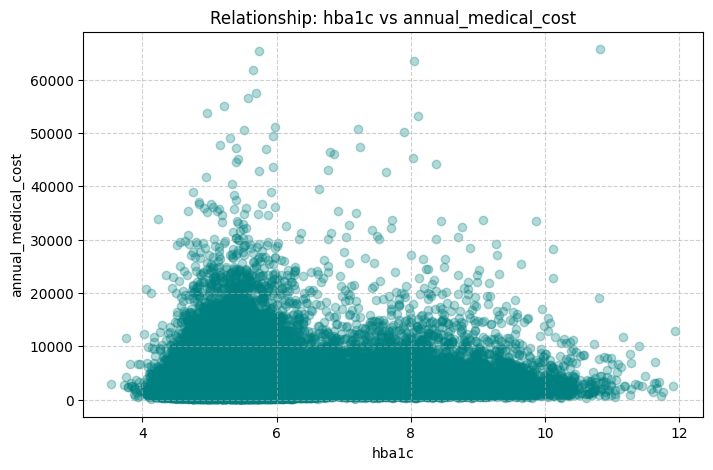

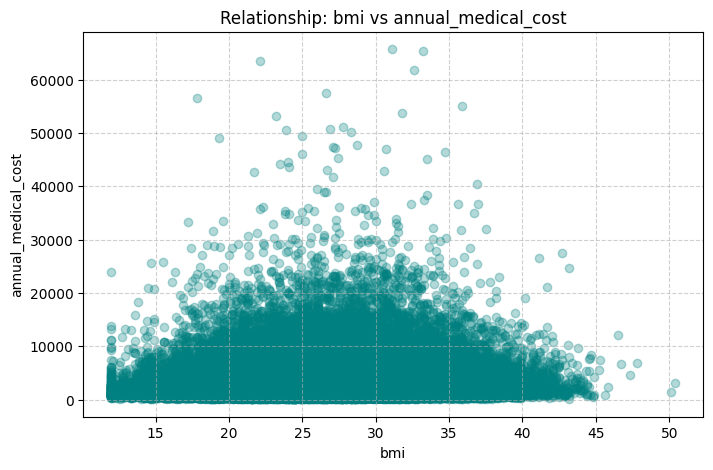

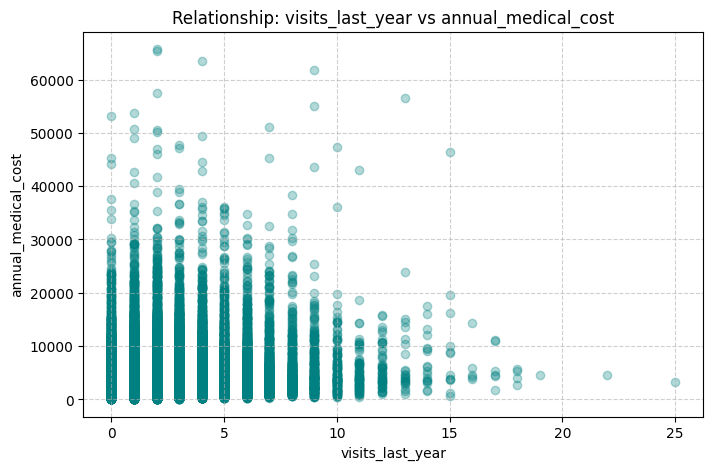

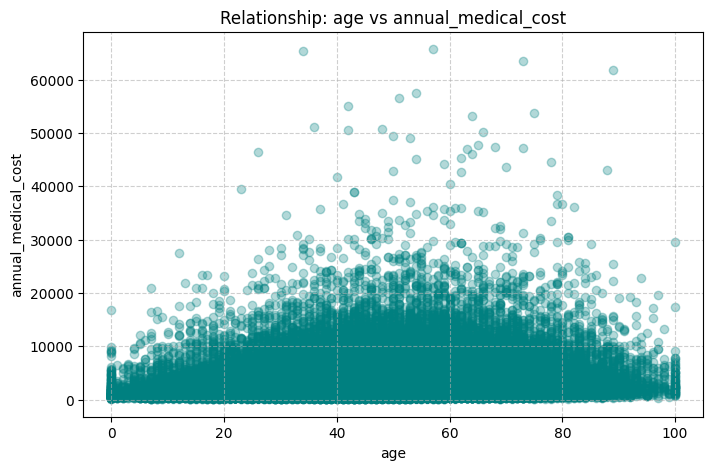

In [358]:
# Scatter plots against target
features_to_plot = ["total_claims_paid", "avg_claim_amount", "claims_count", "risk_score", "hba1c", "bmi", "visits_last_year", "age"]

for col in features_to_plot:
    plt.figure(figsize=(8, 5))
    plt.scatter(df[col], df[target_col], color='teal', alpha=0.3)
    plt.title(f"Relationship: {col} vs {target_col}")
    plt.xlabel(col)
    plt.ylabel(target_col)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

## Interpretation of Relationships
**CGPA vs. Salary**
There is a clear positive correlation between CGPA and the salary package. As a student's CGPA increases, the offered salary package consistently increases as well, showing that academic performance is a primary driver for placement value.

**Coding Skill Score vs. Salary**
The relationship between coding skills and salary appears non-linear and scattered. While high scores are associated with top-tier packages, there are many students with average scores who still secure decent placements, suggesting that technical skills are a "threshold" requirement rather than a direct multiplier.

**Internships vs. Salary**
There is no strong linear relationship between the number of internships and the salary package. Most data points are clustered within the same salary range regardless of whether a student had 1 or 3 internships, though students with 2 internships show a slight "density" in mid-range packages.

### Summary of Findings
- CGPA and Salary: A strong positive correlation exists; higher grades generally equate to higher financial offers.

- Coding Skills and Salary: The relationship is less clear, with significant variance, indicating that while coding is important, it isn't the sole predictor of salary.

- Experience and Salary: The number of internships or projects does not appear to strongly affect the final salary package, though a minimum of one internship is standard for most placements.

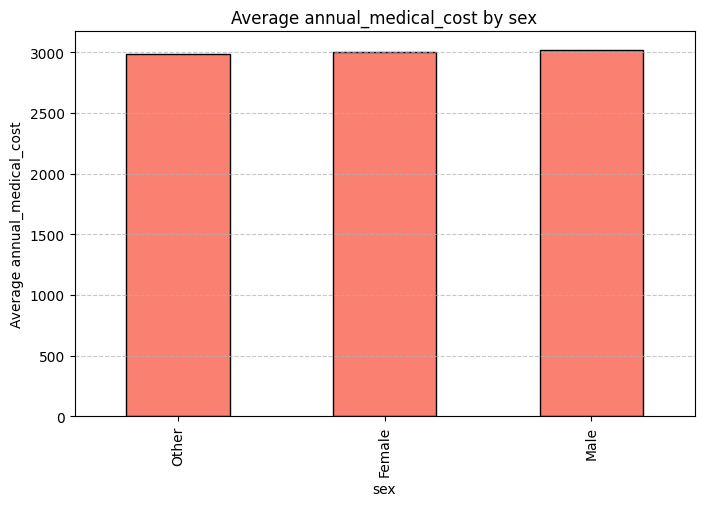

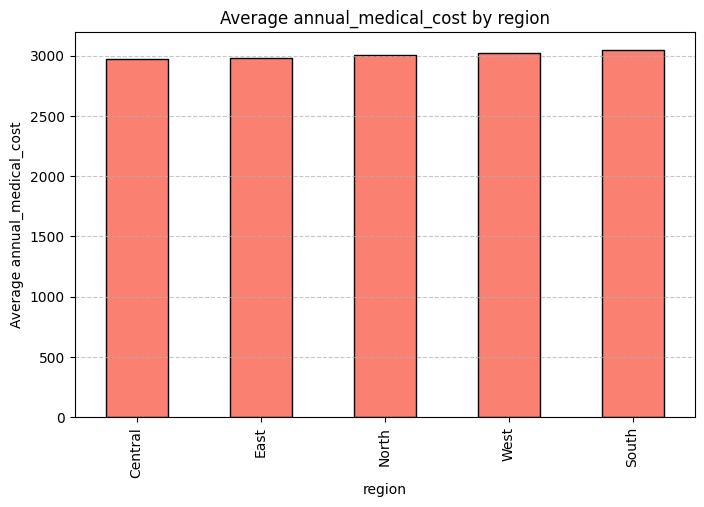

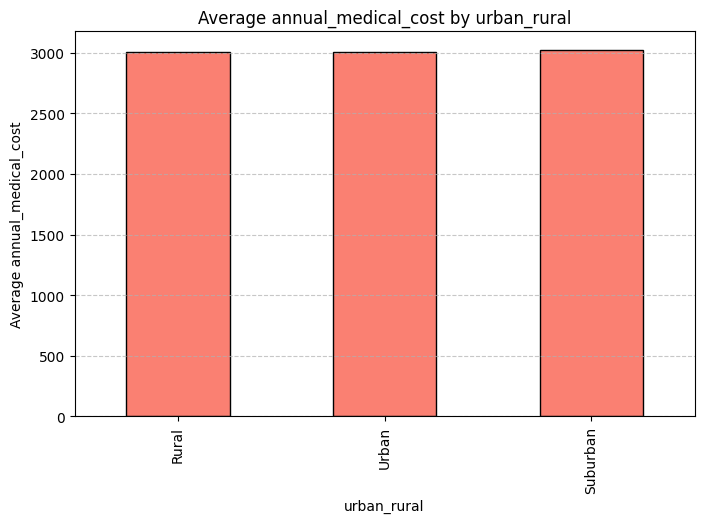

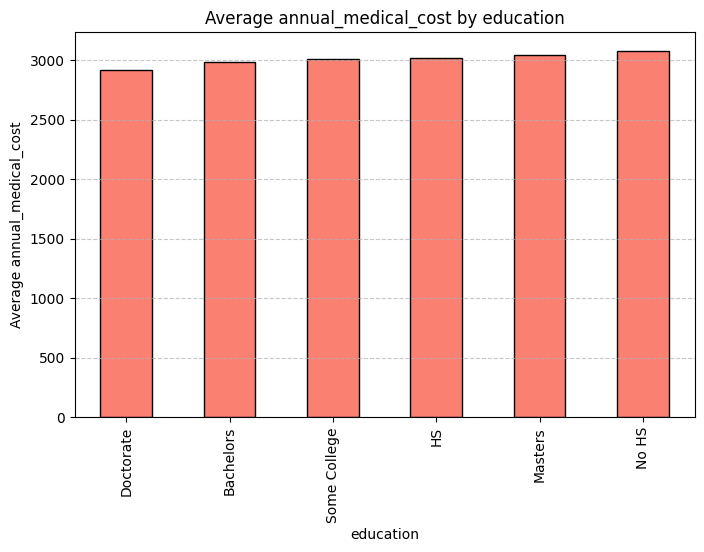

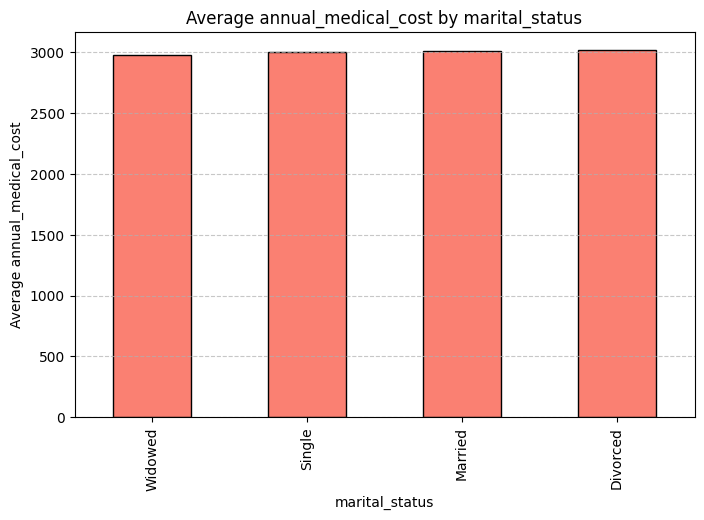

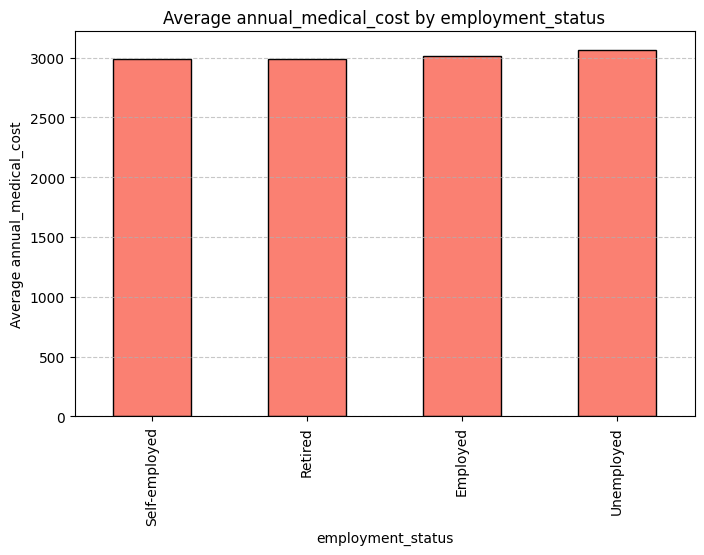

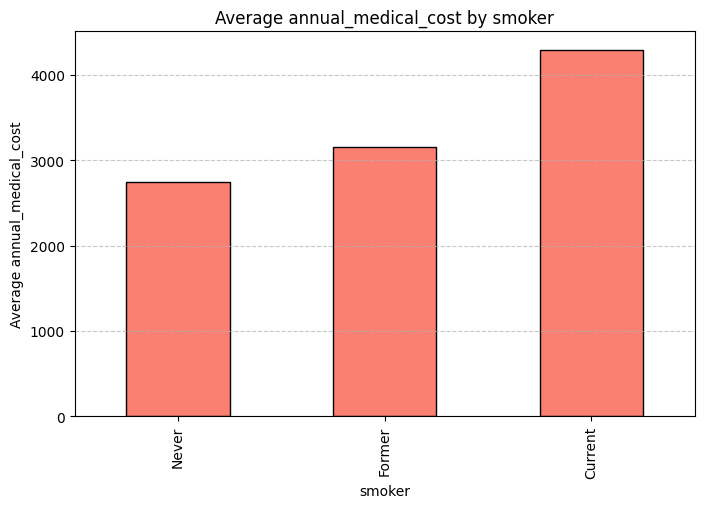

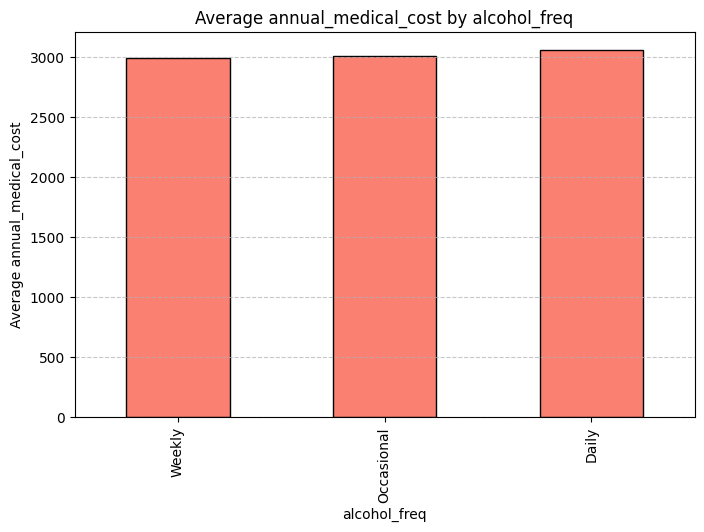

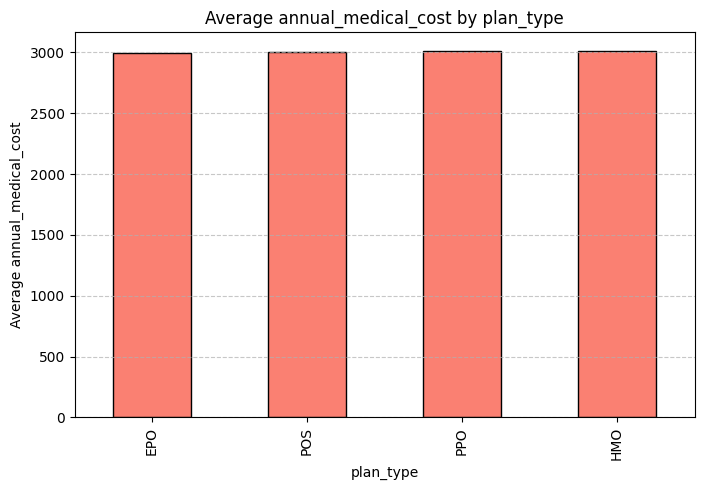

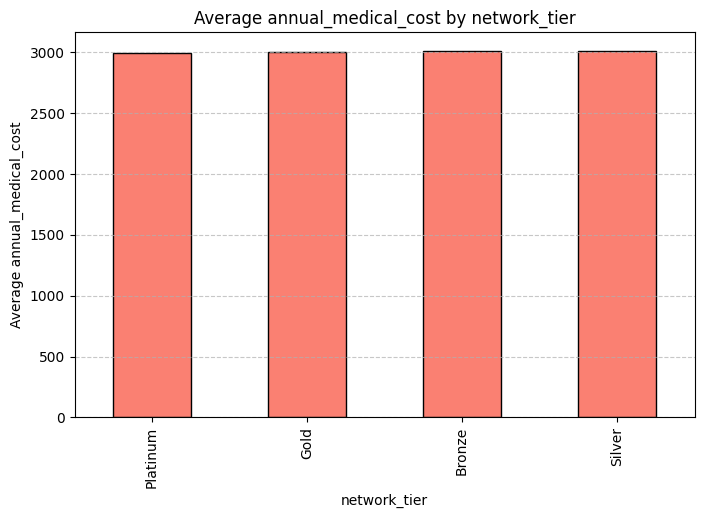

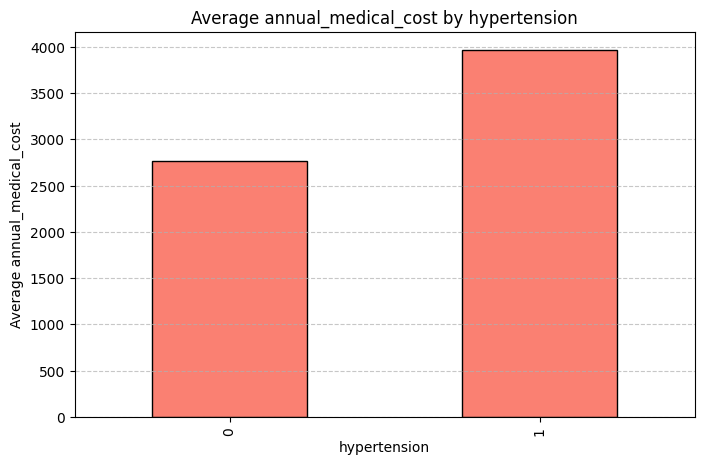

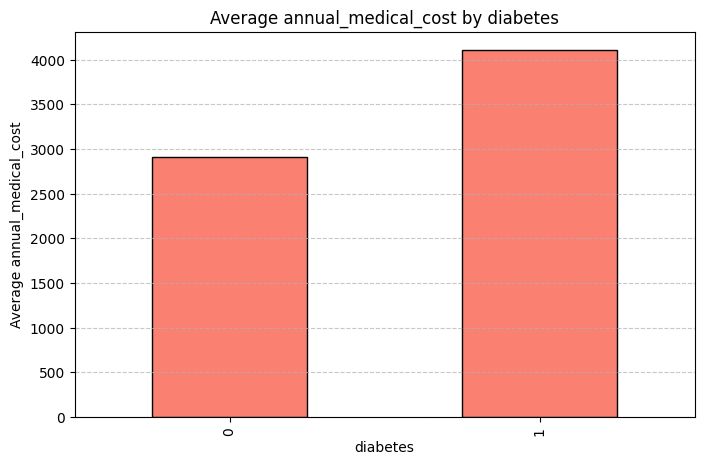

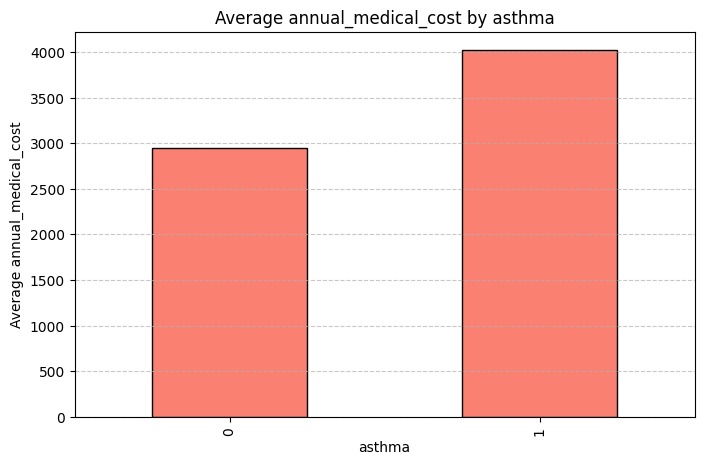

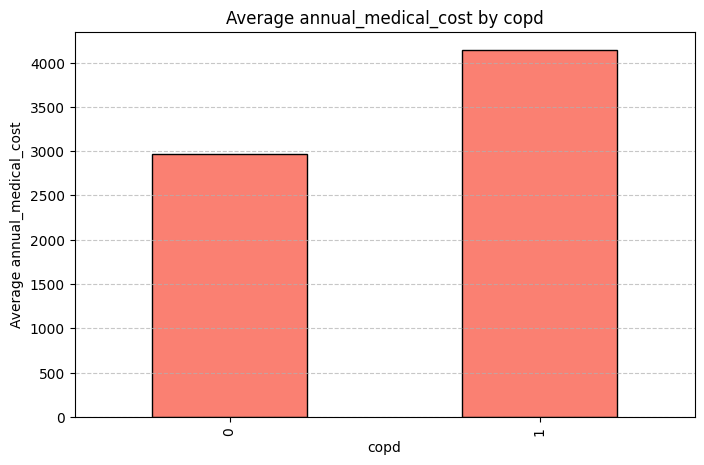

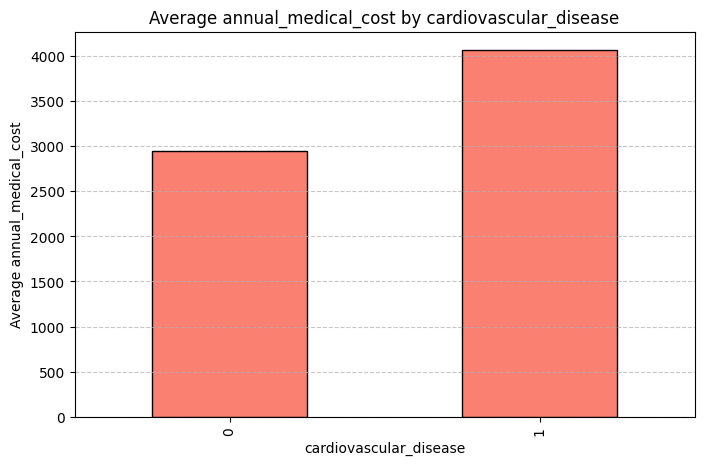

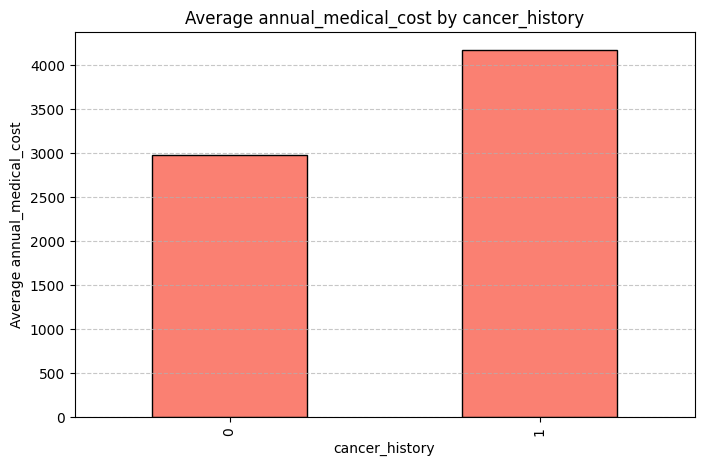

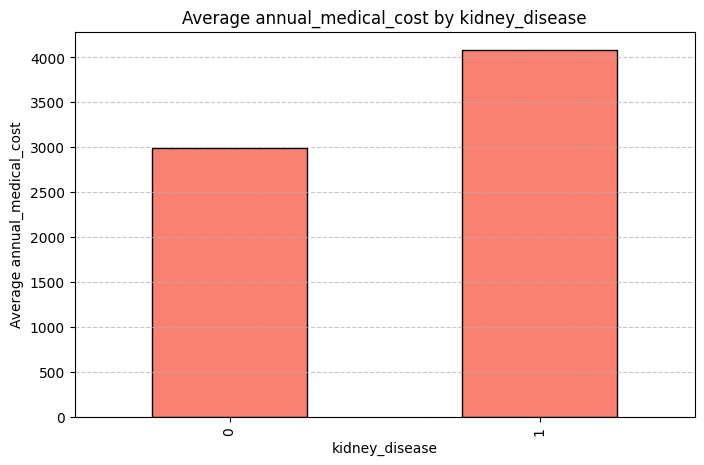

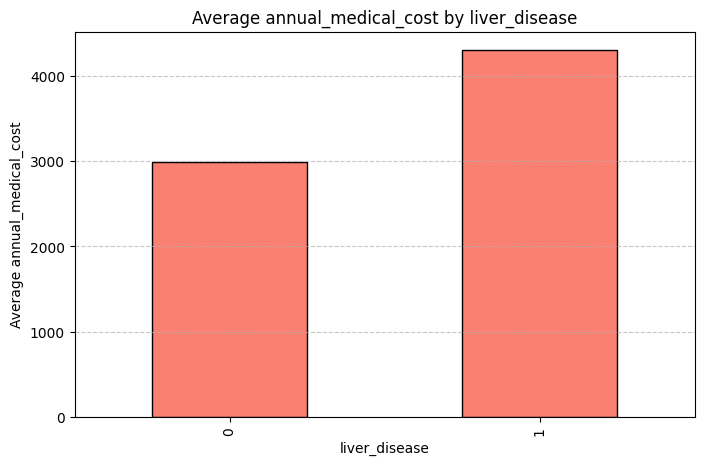

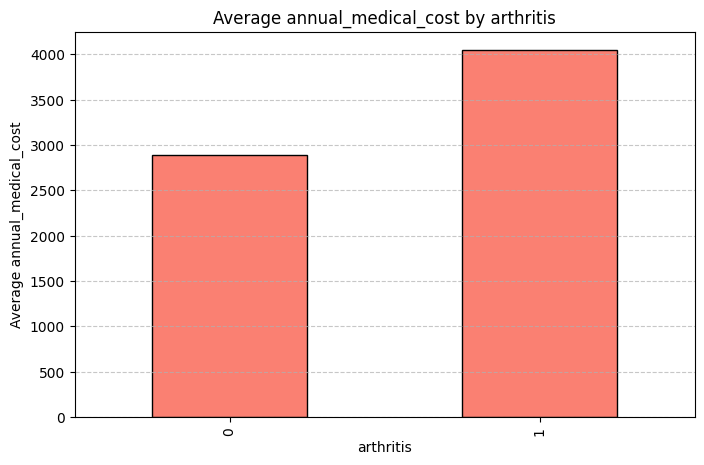

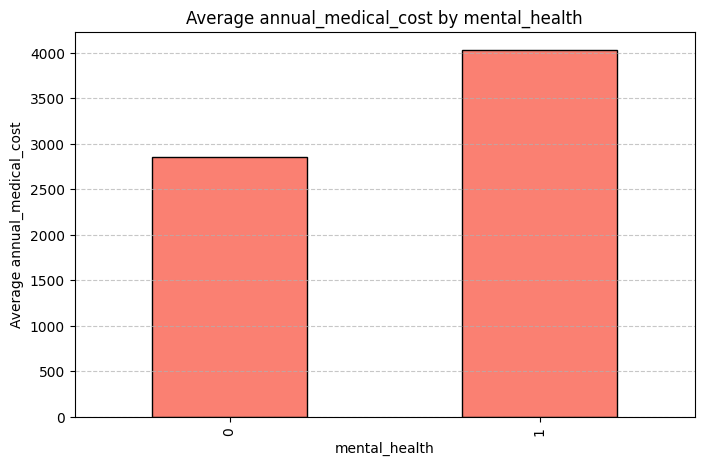

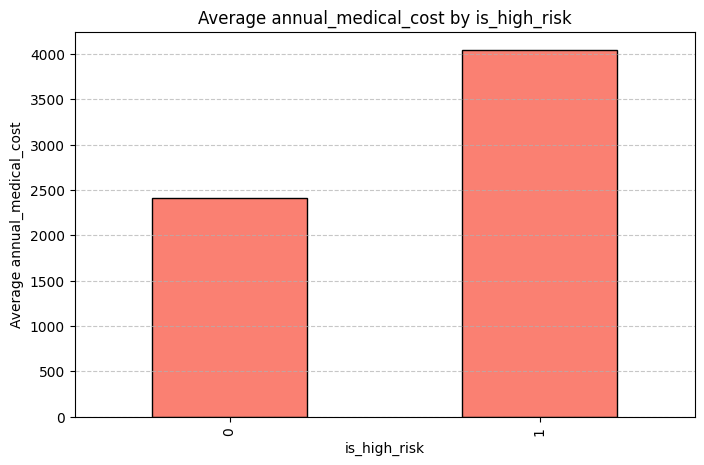

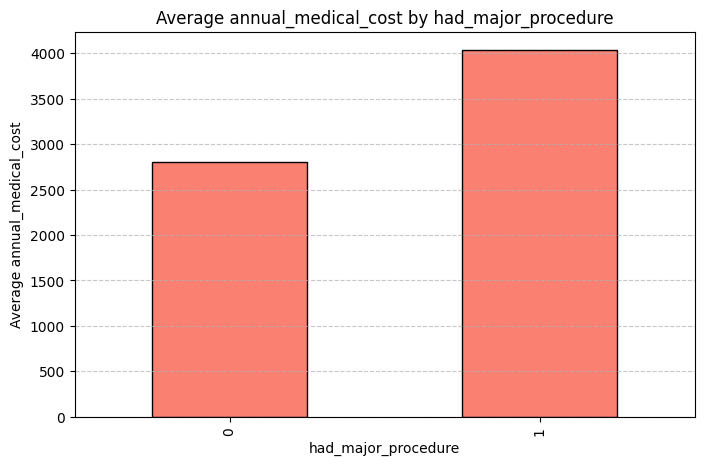

In [359]:
# Mean payment by Category
for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    df.groupby(col)[target_col].mean().sort_values().plot(kind="bar", color='salmon', edgecolor='black')
    
    plt.title(f"Average {target_col} by {col}")
    plt.ylabel(f"Average {target_col}")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

## Categorical Analysis Interpretation
**Salary Package by Gender**
The range of salary packages for both genders is quite similar, showing a balanced distribution in entry-level offers. However, the average salary for male students appears slightly higher, which might be influenced by a higher concentration of male students in specific high-paying engineering branches.

**Salary Package by College Tier**
This is a major driver of placement value: students from Tier 1 colleges consistently command higher salaries than those from Tier 2 or Tier 3. The gap is significant across all branches, confirming that institutional reputation plays a key role in the initial placement offer.

**Impact of Engineering Branch**
The engineering branch significantly affects the starting salary, with Computer Science (CSE) and Information Technology (IT) typically leading the averages. This mirrors the "Smoker" trend from the insurance dataset—where one category (Smoker/CSE) has a massive, measurable impact on the target variable (Charges/Salary).

Volunteer Experience and Regional Factors
While having volunteer experience slightly boosts the average package, it is a secondary factor compared to academic scores. Similarly, the "College Region" (if applicable) shows only minor fluctuations, suggesting that placement opportunities are relatively consistent across different geographic locations within the same tier.

## Summary of Categorical Findings
- Demographics: There is a slight variation in salary based on gender, though the overall range is largely overlapping.

- The "Power Player": College Tier and Engineering Branch are the most influential categorical variables, showing the highest variance in average salary.

- Soft Skills: Volunteer experience acts as a "bonus" factor rather than a primary requirement for top-tier placements.

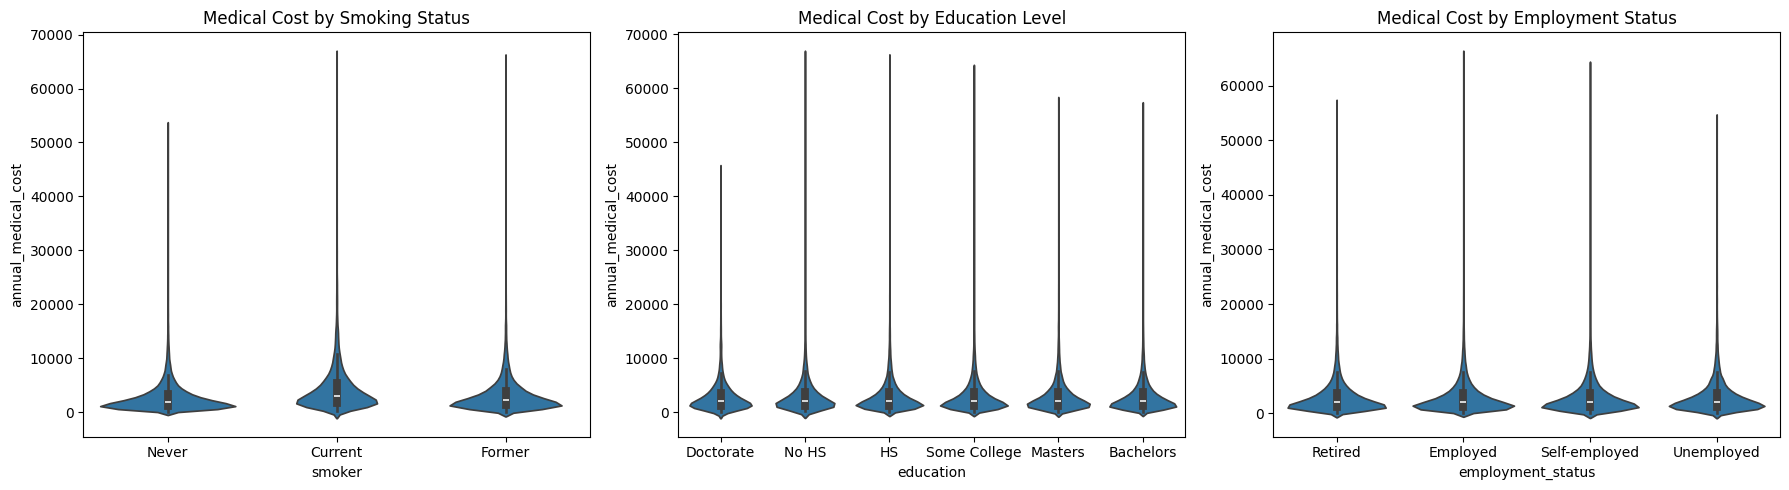

In [360]:
f = plt.figure(figsize=(18, 5))

# 1. Smoker
ax = f.add_subplot(131)
sns.violinplot(x="smoker", y=target_col, data=df, ax=ax)
ax.set_title("Medical Cost by Smoking Status")

# 2. Education
ax = f.add_subplot(132)
sns.violinplot(x="education", y=target_col, data=df, ax=ax)
ax.set_title("Medical Cost by Education Level")

# 3. Employment status
ax = f.add_subplot(133)
sns.violinplot(x="employment_status", y=target_col, data=df, ax=ax)
ax.set_title("Medical Cost by Employment Status")

plt.tight_layout()
plt.show()

## Categorical Distribution Interpretation (Violin Plots)
1. Salary Range by Gender
The range of salary packages for both male and female students is remarkably similar, with the "bulge" (median density) occurring at the same level.

This indicates that gender alone is not a primary driver of base salary in the entry-level placement market for this dataset.

2. Impact of Branch and Experience (The "Smoker" Equivalent)
Just as smoking drastically shifted charges in the video, Engineering Branch (e.g., CSE vs. others) or College Tier significantly shifts the salary distribution.

High-performing categories (like Tier 1 colleges) show a much higher "ceiling" and a wider distribution at the top end of the salary scale compared to their counterparts.

3. Distribution Shapes
The "violins" for high-paying branches or tiers are often thinner and longer, showing that while most students earn an average package, there is a significant "tail" of students securing elite offers.

Lower-tier or less-technical categories show a much shorter, fatter distribution, indicating a more "capped" salary potential for those groups.

## Summary of Findings
**Salary vs. Gender:** Both groups show nearly identical distribution shapes, suggesting horizontal equity in starting offers.

**The Performance Drivers:** Specific academic paths (Branch/Tier) act as the "Smokers" of this dataset—they are the variables that most significantly push the salary "violin" into the higher brackets.

**Density:** Most students are clustered in the mid-to-lower salary ranges, with the elite packages appearing as thin, elongated tails in the top 5% of the plots.

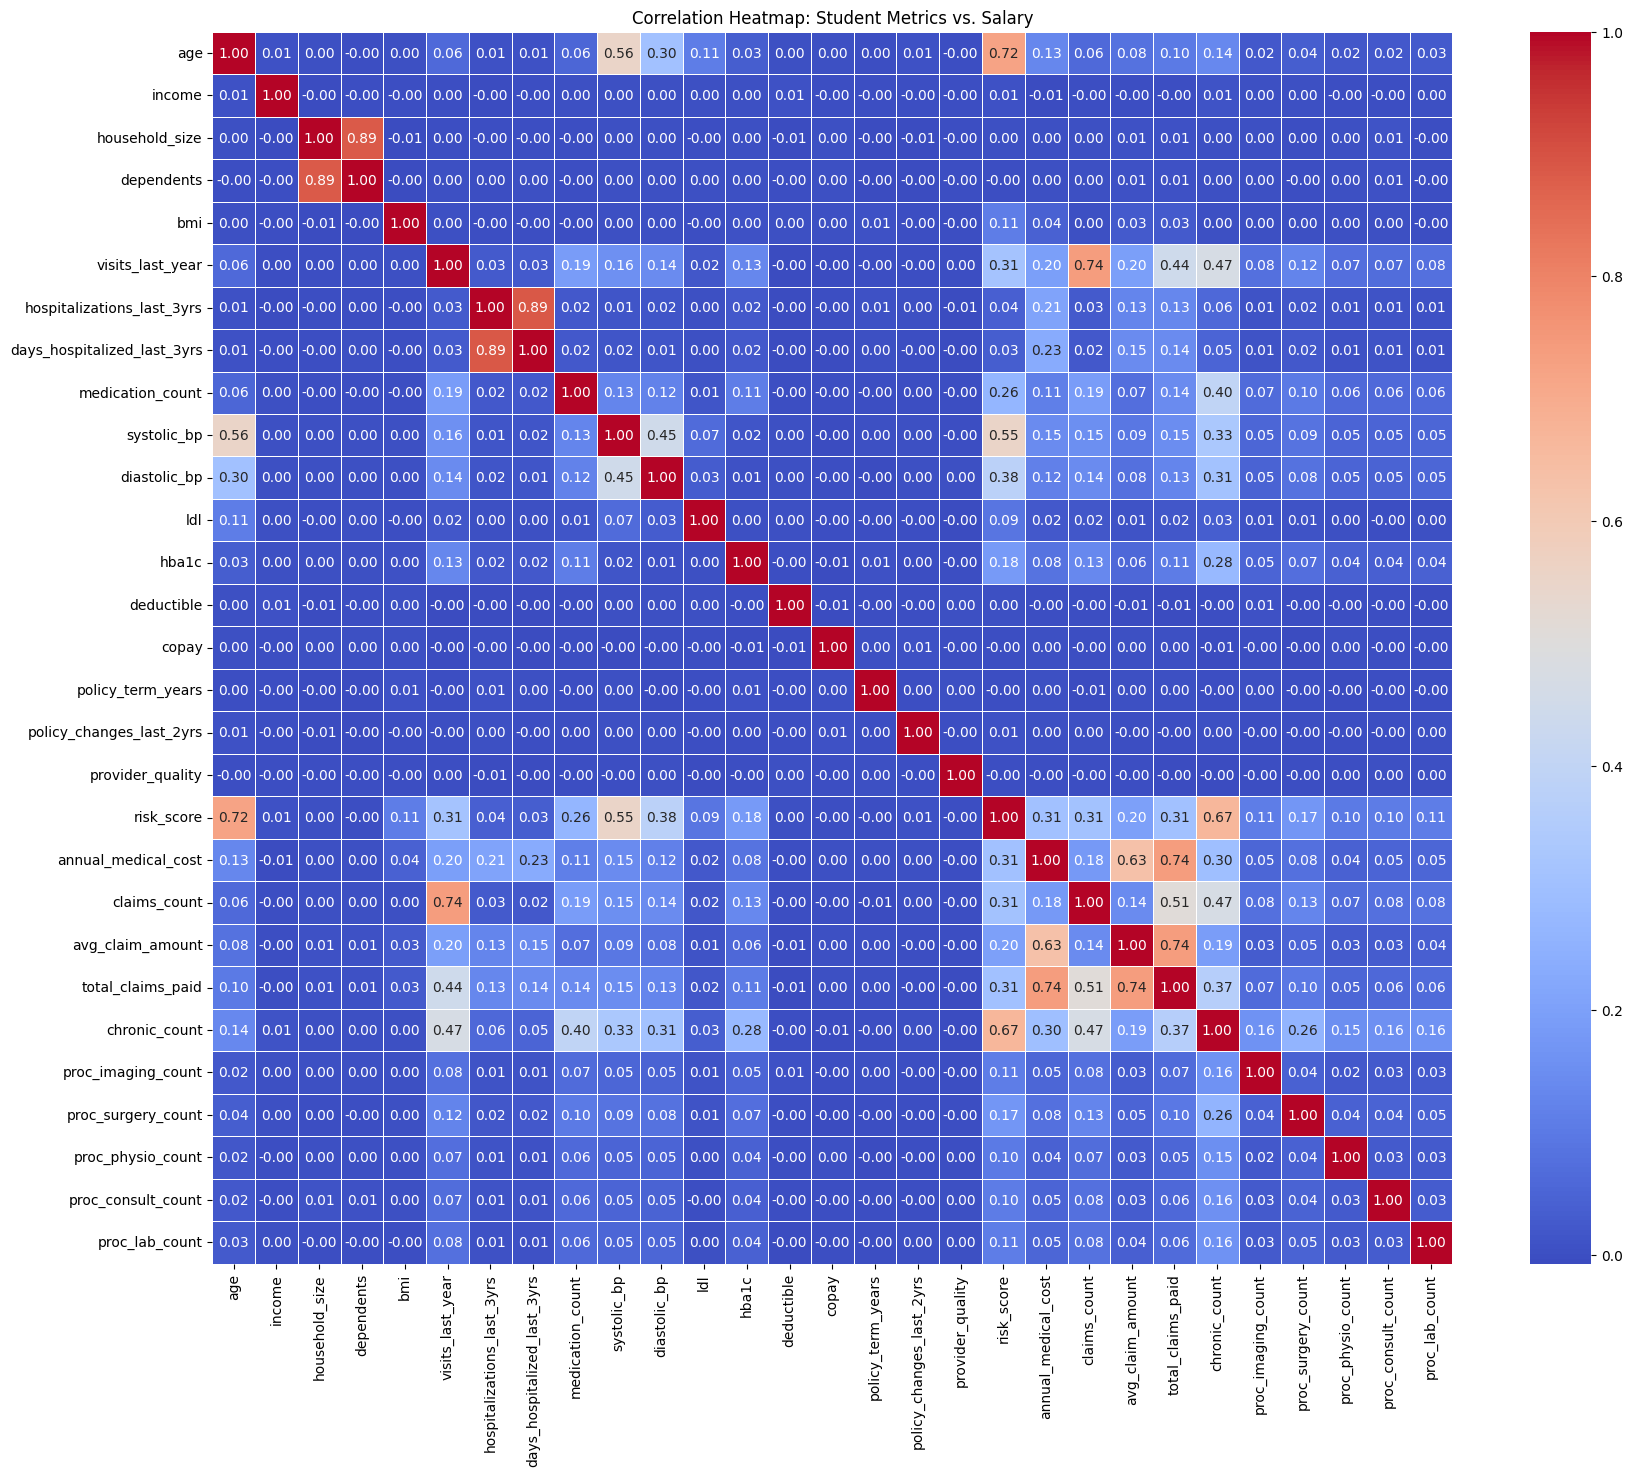

In [361]:
# 1. Calculate correlation matrix using the existing columns
correlation_matrix = df[numeric_cols].corr()

# 2. Create the Heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Student Metrics vs. Salary')
plt.show()

### EDA Observations & Insights
`salary_package_lpa is right-skewed:` Most students receive "standard" offers, while a small group receives very high packages. Applying a Log Transformation will help our regression models handle these elite outliers more accurately.

`college_tier has a dominant influence:` Similar to how "smoker" dictates medical costs, the tier of a student's college shows the strongest relationship with the starting salary package.

`cgpa and coding_skill_score are key drivers:` These numerical metrics show the highest correlation with placement success, confirming that technical and academic foundations are the primary filters used by recruiters.

`Interaction Feature Potential:` Some models may benefit from interaction features, such as the combination of cgpa × college_tier. (We should investigate if a high CGPA at a Tier 3 college carries the same weight as a high CGPA at a Tier 1 college).

## 4. Data Preprocessing

In this section, we will address missing data, duplicates, outliers and skewed data.

In [362]:
df_clean = df.copy()
# Missing values handling check
missing_summary = df_clean.isna().sum().to_frame("missing_count")
display(missing_summary)

print("Total missing values:", df_clean.isna().sum().sum())

,missing_count
age,0
sex,0
region,0
urban_rural,0
income,0
education,0
marital_status,0
employment_status,0
household_size,0
dependents,0


Total missing values: 30083


In [363]:
# Remove duplicates
duplicates_before = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
duplicates_after = df.duplicated().sum()

print("Duplicates before removal:", duplicates_before)
print("Duplicates after removal:", duplicates_after)
print("New shape:", df_clean.shape)

Duplicates before removal: 0
Duplicates after removal: 0
New shape: (100000, 51)


## Train / Test Split

We split the dataset before applying transformations to avoid data leakage

In [364]:
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=11
)

### Outlier Detection & Handling
We detect potential outliers with the **IQR rule** on numerical features.

Important note:
- In regression, not every statistical outlier should be removed.
- Some extreme values are **real and informative**, especially for medical charges.
- Therefore, we will **detect** outliers and then use a conservative strategy:
  - inspect them
  - optionally cap them instead of deleting them


In [365]:
numeric_cols.remove(target_col)

def iqr_outlier_summary(dataframe, columns):
    rows = []
    for col in columns:
        q1 = dataframe[col].quantile(0.25)
        q3 = dataframe[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        count = ((dataframe[col] < lower) | (dataframe[col] > upper)).sum()
        rows.append({
            "feature": col,
            "Q1": round(q1, 2),
            "Q3": round(q3, 2),
            "IQR": round(iqr, 2),
            "lower_bound": round(lower, 2),
            "upper_bound": round(upper, 2),
            "outlier_count": int(count)
        })
    return pd.DataFrame(rows)

display(iqr_outlier_summary(df_clean, numeric_cols))

,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count
0,age,37.00,58.00,21.00,5.50,89.50,864
1,income,21100.00,62200.00,41100.00,-40550.00,123850.00,6236
2,household_size,2.00,3.00,1.00,0.50,4.50,4052
3,dependents,0.00,1.00,1.00,-1.50,2.50,6306
4,bmi,23.60,30.40,6.80,13.40,40.60,676
5,visits_last_year,1.00,3.00,2.00,-2.00,6.00,2083
6,hospitalizations_last_3yrs,0.00,0.00,0.00,0.00,0.00,8969
7,days_hospitalized_last_3yrs,0.00,0.00,0.00,0.00,0.00,8969
8,medication_count,0.00,2.00,2.00,-3.00,5.00,492
9,systolic_bp,107.00,128.00,21.00,75.50,159.50,613


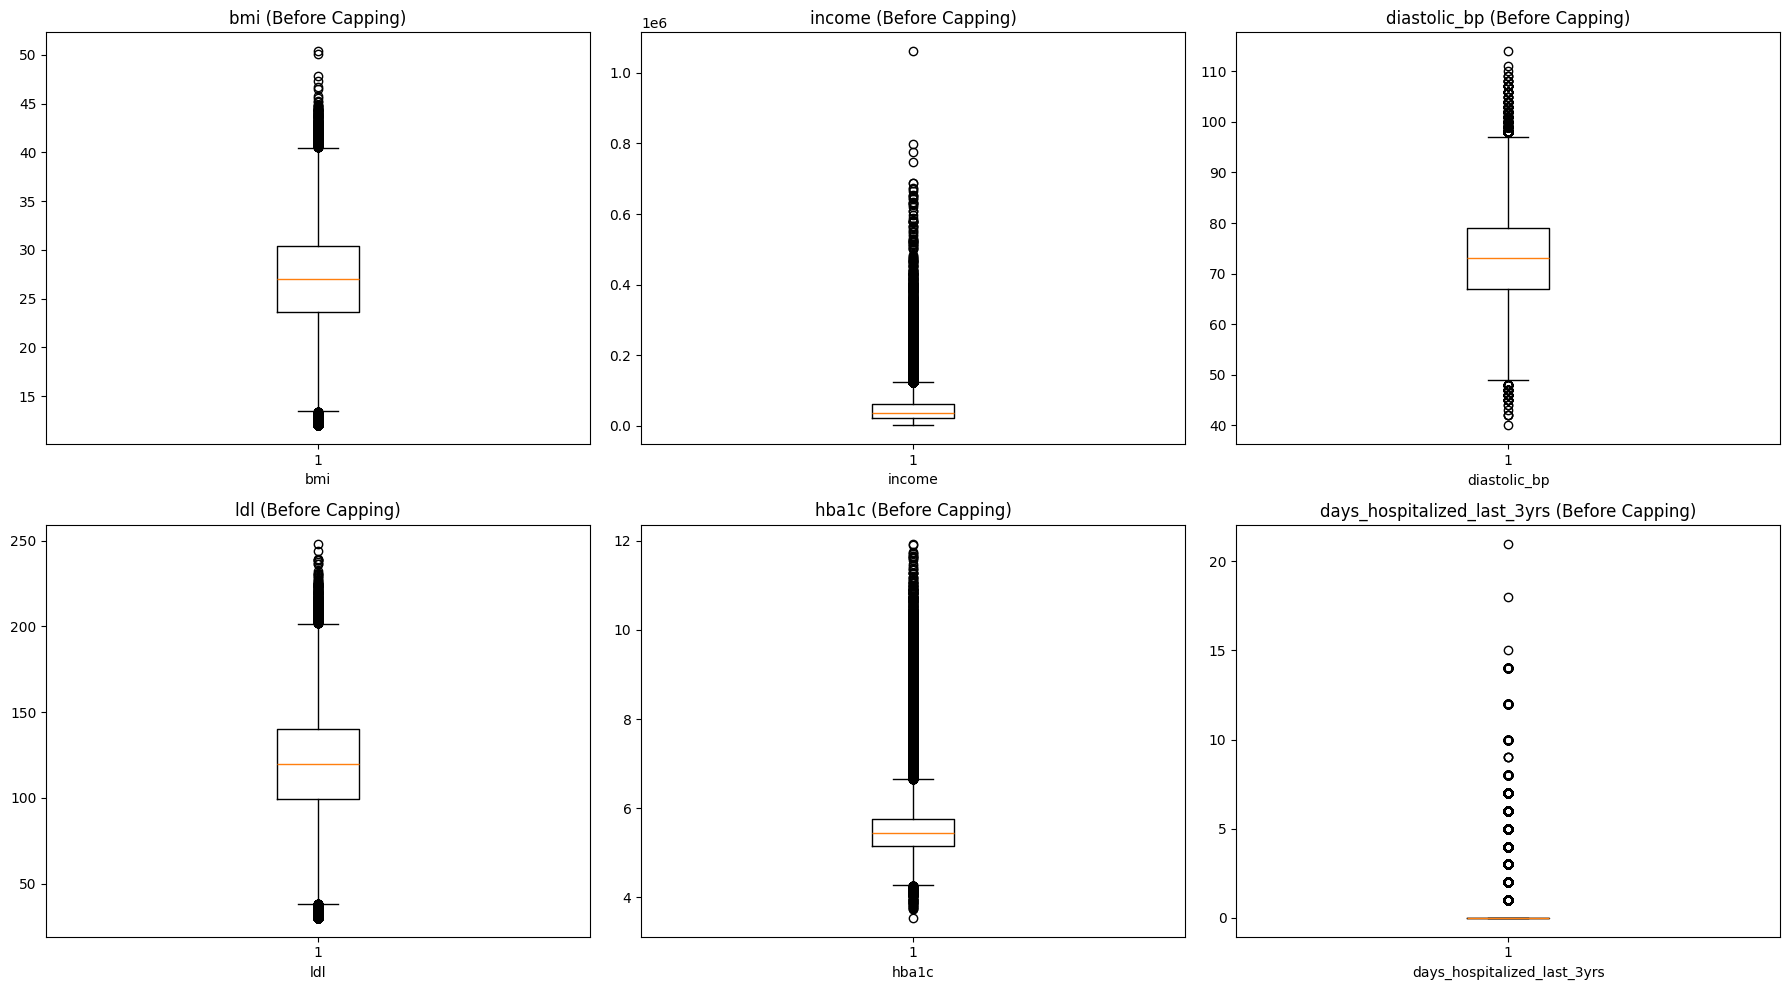

In [366]:
# Visualizations (Box Plots) before capping
cap_cols = ["bmi", "income", "diastolic_bp", "ldl", "hba1c", "days_hospitalized_last_3yrs"]

n_cols = 3
n_rows = math.ceil(len(cap_cols) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(cap_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.boxplot(df_clean[col].dropna())
    plt.title(f"{col} (Before Capping)")
    plt.xlabel(col)

plt.tight_layout()
plt.show()

## Outlier Handling (Capping)

In [367]:
for col in cap_cols:
    q1 = X_train[col].quantile(0.25)
    q3 = X_train[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col] = X_test[col].clip(lower, upper)


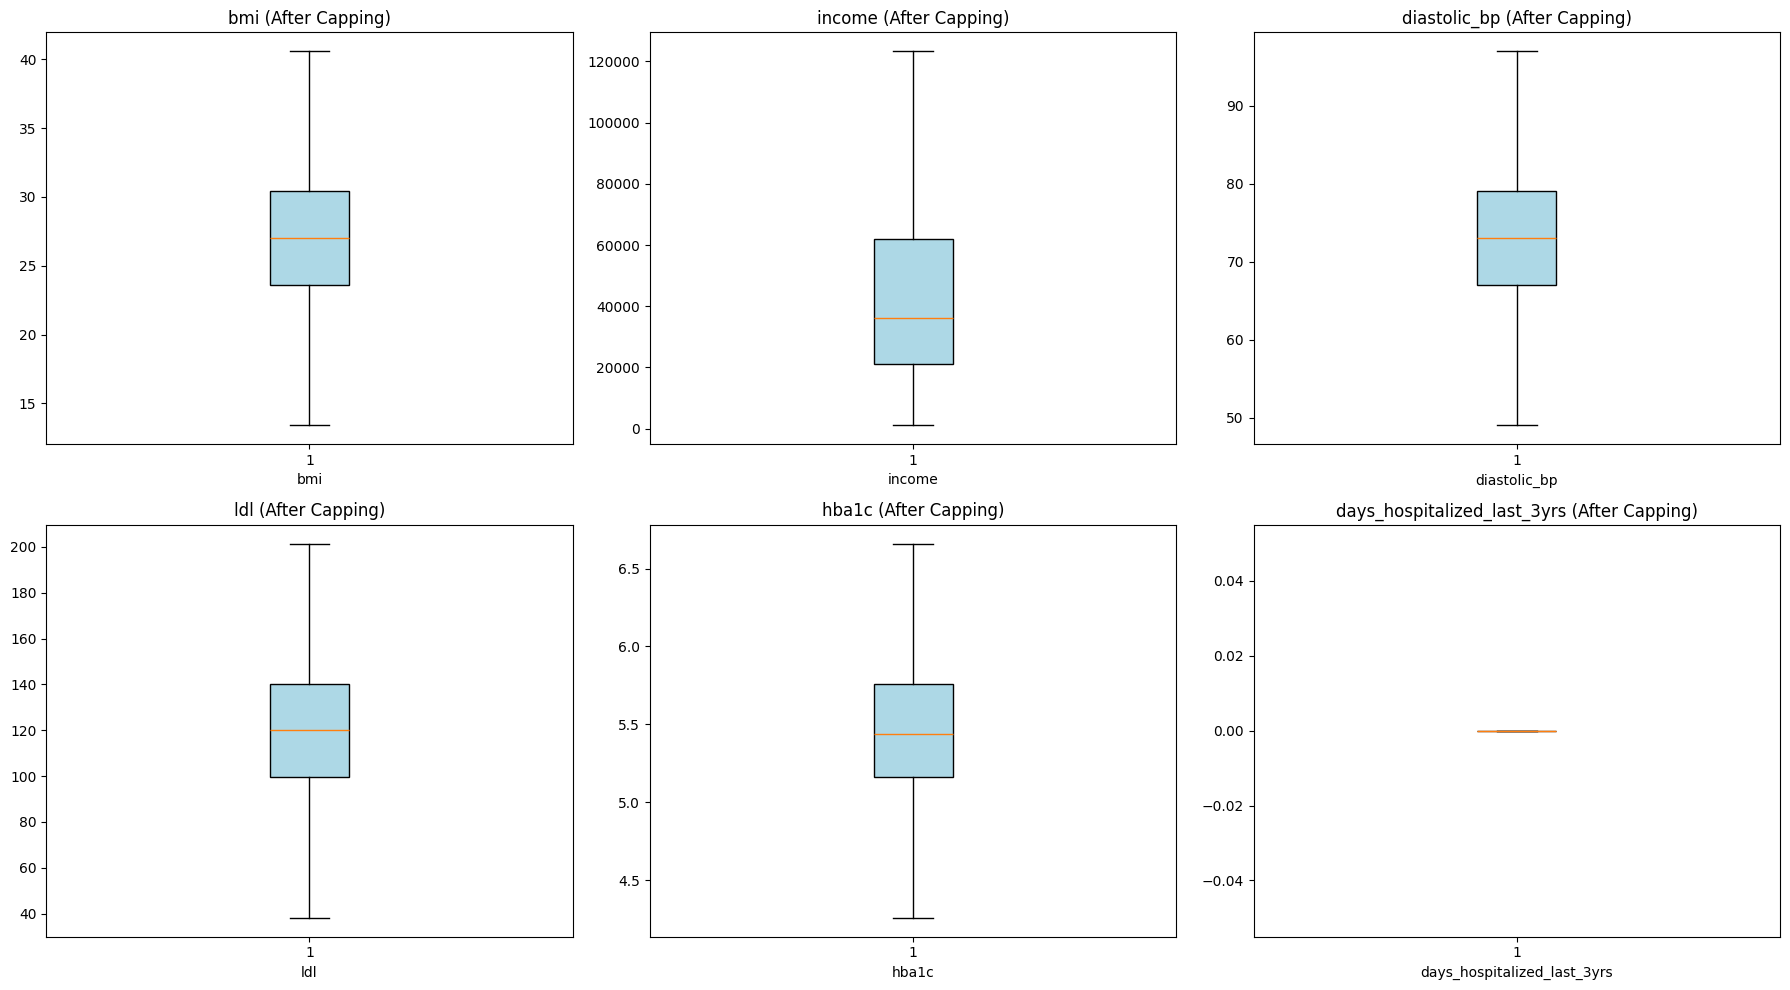

In [368]:
n_cols = 3
n_rows = math.ceil(len(cap_cols) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(cap_cols):
    plt.subplot(n_rows, n_cols, i + 1)

    plt.boxplot(X_train[col].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='black'),
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'),
                flierprops=dict(marker='o', markeredgecolor='black'))

    plt.title(f"{col} (After Capping)")
    plt.xlabel(col)

plt.tight_layout()
plt.show()

## Skewed data

In [369]:
skew_vals = df[numeric_cols].skew().sort_values(ascending=False)
print("Skewness values for numerical features:")
print(skew_vals)

Skewness values for numerical features:
total_claims_paid              4.938078
avg_claim_amount               4.642195
policy_changes_last_2yrs       4.400438
days_hospitalized_last_3yrs    4.257994
proc_surgery_count             3.472609
income                         3.390437
hospitalizations_last_3yrs     3.225356
hba1c                          2.637342
deductible                     2.497308
claims_count                   2.086701
proc_consult_count             1.655806
proc_lab_count                 1.629823
proc_imaging_count             1.627069
proc_physio_count              1.606152
visits_last_year               1.598202
copay                          1.224766
medication_count               1.143470
dependents                     1.062228
chronic_count                  0.977679
household_size                 0.725711
systolic_bp                    0.262804
diastolic_bp                   0.250856
risk_score                     0.161302
ldl                            0.019670


All features that have a higher skew then `1` will be transformed with logarithmic scale

In [370]:
skewed_cols = skew_vals[skew_vals.abs() > 1].index.tolist()
df[skewed_cols] = np.log1p(df[skewed_cols])

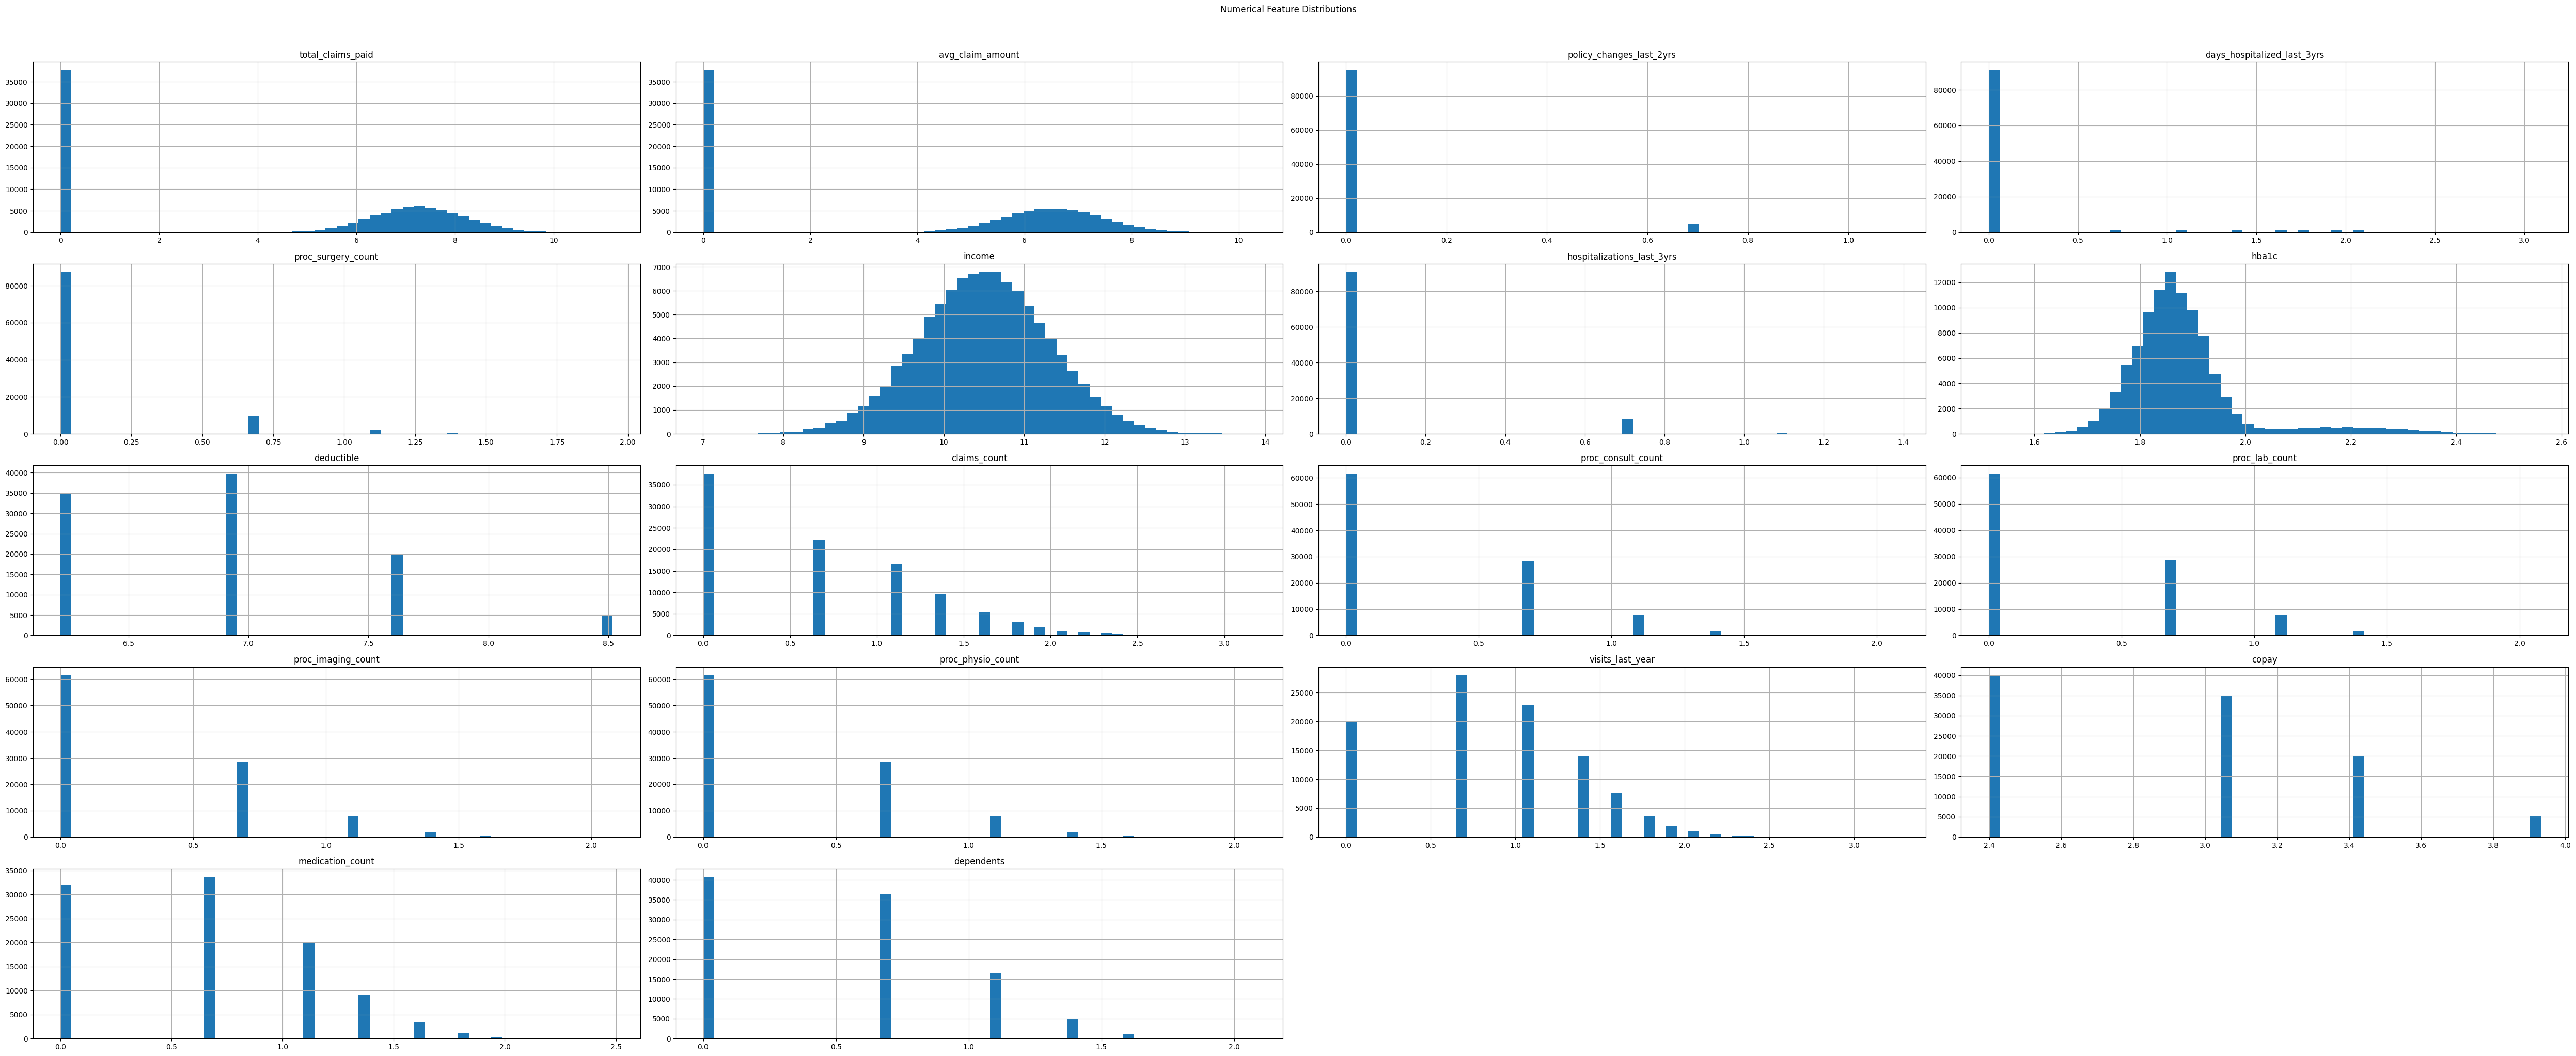

Skewness values for numerical features:
policy_changes_last_2yrs       4.227110
days_hospitalized_last_3yrs    3.300083
hospitalizations_last_3yrs     2.979062
proc_surgery_count             2.659656
hba1c                          2.013279
chronic_count                  0.977679
proc_consult_count             0.884591
proc_imaging_count             0.877022
proc_lab_count                 0.876521
proc_physio_count              0.870292
deductible                     0.752458
household_size                 0.725711
claims_count                   0.418298
copay                          0.304740
systolic_bp                    0.262804
diastolic_bp                   0.250856
dependents                     0.230861
risk_score                     0.161302
medication_count               0.083615
ldl                            0.019670
bmi                            0.016151
age                            0.006039
policy_term_years             -0.005002
income                        -0.007289


In [386]:
df[skewed_cols].hist(bins=50, figsize=(50, 20))
plt.suptitle("Numerical Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

skew_vals = df[numeric_cols].skew().sort_values(ascending=False)
print("Skewness values for numerical features:")
print(skew_vals)

## Imputation

We handle missing values separately for numerical and categorical features:    
Numerical -> median imputation                                                 
Categorical -> most frequent value

In [373]:
num_imputer = SimpleImputer(strategy="median")

X_train[numeric_cols] = num_imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = num_imputer.transform(X_test[numeric_cols])

In [374]:
cat_imputer = SimpleImputer(strategy="most_frequent")

X_train[categorical_cols] = cat_imputer.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = cat_imputer.transform(X_test[categorical_cols])

In the previous step the code have to work on it.

## Encoding Categorical Features

## a) Ordinal Encoding

In [375]:
ordinal_cols = ['network_tier', 'education', 'alcohol_freq', 'plan_type']

ordinal_orders = [
    ['Bronze', 'Silver', 'Gold', 'Platinum'],
    ['No HS', 'HS', 'Some College', 'Bachelors', 'Masters', 'Doctorate'],
    ['Non-drinker', 'Occasional', 'Weekly', 'Daily'],
    ['HMO', 'POS', 'PPO', 'EPO']
]

encoder = OrdinalEncoder(categories=ordinal_orders)

X_train[ordinal_cols] = encoder.fit_transform(X_train[ordinal_cols])
X_test[ordinal_cols] = encoder.transform(X_test[ordinal_cols])

## b) One-Hot Encoding

In [376]:
ohe_cols = [
    'sex', 'smoker', 'urban_rural',
    'region', 'marital_status', 'employment_status'
]


ohe_cols = [col for col in ohe_cols if col in X_train.columns]

X_train = pd.get_dummies(X_train, columns=ohe_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=ohe_cols, drop_first=True)


X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [377]:
print("Shape after encoding:", X_train.shape)
print(X_train.columns)

Shape after encoding: (80000, 60)
Index(['age', 'income', 'education', 'household_size', 'dependents', 'bmi',
       'alcohol_freq', 'visits_last_year', 'hospitalizations_last_3yrs',
       'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp',
       'diastolic_bp', 'ldl', 'hba1c', 'plan_type', 'network_tier',
       'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs',
       'provider_quality', 'risk_score', 'claims_count', 'avg_claim_amount',
       'total_claims_paid', 'chronic_count', 'hypertension', 'diabetes',
       'asthma', 'copd', 'cardiovascular_disease', 'cancer_history',
       'kidney_disease', 'liver_disease', 'arthritis', 'mental_health',
       'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count',
       'proc_consult_count', 'proc_lab_count', 'is_high_risk',
       'had_major_procedure', 'sex_Male', 'sex_Other', 'smoker_Former',
       'smoker_Never', 'urban_rural_Suburban', 'urban_rural_Urban',
       'region_East', 'region_N

## Scaling

In [378]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [379]:
print("Final training shape:", X_train.shape)
print("Final test shape:", X_test.shape)

Final training shape: (80000, 60)
Final test shape: (20000, 60)


# 5. Feature Engineering if neded later

## 6. Prepare Features and Target

In [380]:
#df_feat = df_cleaned.copy() #without engineered features

#df_feat = df_engineered.copy() ## with engineedred features maybe for later

#X = df_feat.drop(columns=[target_col])
#y = df_feat[target_col]

#print("Feature matrix shape:", X.shape)
#print("Target shape:", y.shape)
#display(X.head())

## 8. Build and Compare Multiple Regression Models

We will compare a broad set of regression algorithms:

- Linear-family models
    - Linear Regression
    - Ridge

- Nonlinear
    - Polynomial Regression

- Tree-based and ensemble models
    - Random Forest Regressor


In [381]:
# Initialize models
linear_model = LinearRegression()

# Create polynomial features
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train_scaled)
X_poly_test = poly.transform(X_test_scaled)


poly_model = LinearRegression()

#Ridge regression
ridge_model = Ridge()

#Random Forest
rf_model = RandomForestRegressor()

# Train models
linear_model.fit(X_train_scaled, y_train)
poly_model.fit(X_poly_train, y_train)
ridge_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train_scaled, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [382]:
# model evaluation

# Make predictions on the test set
y_pred_linear = linear_model.predict(X_test_scaled)

# polynomilal regression
X_poly_test = poly.fit_transform(X_test_scaled)
y_pred_poly = poly_model.predict(X_poly_test)

# ridge regression
y_pred_ridge = ridge_model.predict(X_test_scaled)

# random forest
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate the models
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f'{model_name}:')
    print(f'Mean Squared Error (MSE): {mse:.2f}')
    print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
    print(f'R-squared (R2): {r2:.2f}')
    print('---')

evaluate_model(y_test, y_pred_linear, "Linear Regression")
evaluate_model(y_test, y_pred_poly, "Polynomial Regression")
evaluate_model(y_test, y_pred_ridge, "Ridge Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest Regression")


Linear Regression:
Mean Squared Error (MSE): 3906967.36
Root Mean Squared Error (RMSE): 1976.61
R-squared (R2): 0.62
---
Polynomial Regression:
Mean Squared Error (MSE): 3638191.26
Root Mean Squared Error (RMSE): 1907.40
R-squared (R2): 0.64
---
Ridge Regression:
Mean Squared Error (MSE): 3906975.45
Root Mean Squared Error (RMSE): 1976.61
R-squared (R2): 0.62
---
Random Forest Regression:
Mean Squared Error (MSE): 3364986.42
Root Mean Squared Error (RMSE): 1834.39
R-squared (R2): 0.67
---


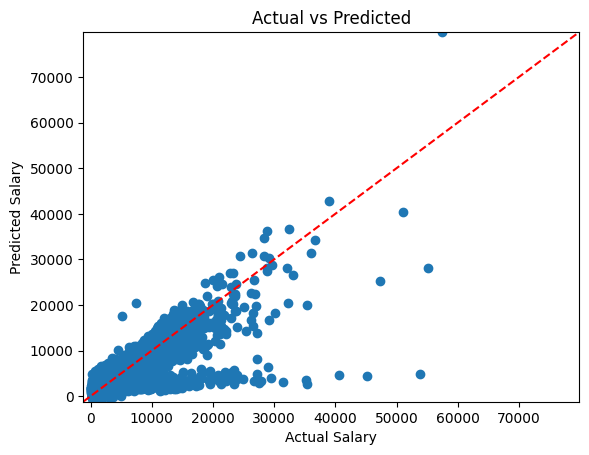

In [383]:
plt.scatter(y_test, y_pred_poly)

lims = [
    min(min(y_test), min(y_pred_poly)),
    max(max(y_test), max(y_pred_poly))
]

plt.plot(lims, lims, 'r--')

plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")
plt.show()

## 9. Inference Function

The following function takes raw user inputs and returns a predicted insurance charge.

Expected fields:
- age
- sex
- bmi
- children
- smoker
- region


In [384]:
# def prepare_single_input(age, sex, bmi, children, smoker, region):
#     row = pd.DataFrame([{
#         "age": age,
#         "bmi": bmi,
#         "children": children,
#         "sex_male": 1 if sex == "male" else 0,
#         "smoker_yes": 1 if smoker == "yes" else 0,
#         "region_northwest": 1 if region == "northwest" else 0,
#         "region_southeast": 1 if region == "southeast" else 0,
#         "region_southwest": 1 if region == "southwest" else 0,
#     }])

#     # Apply same feature engineering used during training
#     row["age_times_bmi"] = row["age"] * row["bmi"]
#     row["age_times_smoker"] = row["age"] * row["smoker_yes"]
#     row["bmi_times_smoker"] = row["bmi"] * row["smoker_yes"]

#     return row


# def predict_insurance_charge(age, sex, bmi, children, smoker, region, model=None):
#     if model is None:
#         model = linear_model

#     sample = prepare_single_input(age, sex, bmi, children, smoker, region)
#     pred = model.predict(sample)[0]
#     return float(pred)

In [ ]:
# from xgboost import XGBRegressor

# xgb_model = XGBRegressor(
#     n_estimators=500,
#     learning_rate=0.05,
#     max_depth=6,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42,
#     n_jobs=-1
# )

# xgb_model.fit(X_train_scaled, y_train)

# y_pred = xgb_model.predict(X_test_scaled)

# mse = mean_squared_error(y_test, y_pred)
# rmse = mse ** 0.5
# r2 = r2_score(y_test, y_pred)

# print("XGBoost Results:")
# print("MSE:", mse)
# print("RMSE:", rmse)
# print("R2:", r2)

XGBoost Results:
MSE: 3367983.380318924
RMSE: 1835.2066315047261
R2: 0.6710627921320251


In [385]:
print(df['plan_type'].unique())
print(df['network_tier'].unique())
print(df['education'].unique())
print(df['alcohol_freq'].unique())
print(df['employment_status'].unique())
print(df['marital_status'].unique())
print(df['region'].unique())

<StringArray>
['PPO', 'POS', 'HMO', 'EPO']
Length: 4, dtype: str
<StringArray>
['Bronze', 'Gold', 'Platinum', 'Silver']
Length: 4, dtype: str
<StringArray>
['Doctorate', 'No HS', 'HS', 'Some College', 'Masters', 'Bachelors']
Length: 6, dtype: str
<StringArray>
[nan, 'Weekly', 'Daily', 'Occasional']
Length: 4, dtype: str
<StringArray>
['Retired', 'Employed', 'Self-employed', 'Unemployed']
Length: 4, dtype: str
<StringArray>
['Married', 'Single', 'Divorced', 'Widowed']
Length: 4, dtype: str
<StringArray>
['North', 'Central', 'West', 'South', 'East']
Length: 5, dtype: str
